# Preprocesamiento, Análisis Exploratorio y Entrenamiento de Modelos

### Estructura del notebook

| Sección | Contenido |
|---|---|
| 0–2 | Instalación, importaciones y parámetros globales |
| 3–6 | Carga, corrección de año, fusión LB × V-Dem, exclusiones |
| 7–8 | Recodificación del target y transformaciones de escala |
| **EDA Parte 1** | Exploración sobre datos transformados pre-split |
| 9–10 | Definición de features y construcción de splits temporales |
| **EDA Parte 2** | Validación post-transformación y selección empírica de features |
| 11–12 | Imputación diferenciada y función de evaluación |
| 13–17 | Cinco modelos con optimización Optuna |
| 18 | Ciclo principal de entrenamiento y guardado del pipeline completo |
| 19–21 | Función de predicción en producción, resultados y visualización |
| 22 | Registro de versiones |

> **Regla de oro anti-data leakage:** toda transformación aprendida (imputador, scaler)
> se ajusta **exclusivamente** sobre el conjunto de entrenamiento de cada split.

## 1. Importaciones

In [1]:
# =============================================================================
# Importaciones globales
# =============================================================================
import os, gc, json, joblib, warnings, logging
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import missingno as msno

from sklearn.experimental import enable_iterative_imputer   # noqa
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, cohen_kappa_score,
    roc_auc_score, mean_absolute_error,
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from tqdm.notebook import tqdm

# Agregar raiz del proyecto al path (funciona en VS Code y Jupyter Lab)
import sys

_root = Path(".").resolve()
if not (_root / "utils").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))


warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("✓ Importaciones completadas.")

✓ Importaciones completadas.


/home/mporras/DemocraticSatisfactionLatam/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuraciones personalizadas

In [2]:
from utils.config import (
    SPLIT, PAISES_EXCLUIR_EVAL, AÑO_CORTE_VEN,
    setup_plots, THEME, PALETTES, PARAMETERS, PATHS,
    MAPEO_NUMINVES, MAPEO_PAIS_ISO3,
    COL_TARGET, COL_AÑO, COL_PAIS, COL_ISO3, COL_PESO, NSNR,
    VARS_EXCLUIR_LB, VARS_EXCLUIR_VDEM,
    VARS_CATEGORICAS, N_CLASES, ETIQUETAS, BLOQUES, ETIQUETAS_FEATURES,
    bloque_de,
)
from utils.plots import save_figure, model_color
from utils.preprocessing import (
    limpiar_nsnr, construir_split, resumen_split, imputar, normalizar,
    aplicar_transformaciones_deterministas,
)
from utils.metrics import evaluar
from utils.models import (
    entrenar_olo, entrenar_xgboost, entrenar_catboost,
    entrenar_lightgbm, entrenar_tabnet, predecir,
)
setup_plots()
print("✓ Utils importados correctamente.")

✓ Utils importados correctamente.


## 2. Parámetros globales del pipeline

> Toda configuración ajustable se concentra aquí.
> Modificar este bloque sin tocar el resto del notebook.

In [3]:
# =============================================================================
# PARÁMETROS GLOBALES — solo configuración de ejecución y hardware
# =============================================================================

np.random.seed(PARAMETERS["SEED"])
torch.manual_seed(PARAMETERS["SEED"])

# ── Hardware ───────────────────────────────────────────────────────────────────
USAR_GPU       = True
DEVICE_CUDA    = "gpu"
DISPOSITIVO_TN = "cuda" if USAR_GPU and torch.cuda.is_available() else "cpu"
N_JOBS         = -1

# ── Directorios ───────────────────────────────────────────────────────────────
for d in [PATHS["FOLDER_PROCS"], PATHS["FOLDER_MODELS"], PATHS["FOLDER_RESULTS"],
          PATHS["FOLDER_RESULTS_FIGURES"], PATHS["FOLDER_RESULTS_METRICS"],
          PATHS["FOLDER_RESULTS_TABLES"]]:
    d.mkdir(parents=True, exist_ok=True)

# ── Flags de ejecución ────────────────────────────────────────────────────────
EJECUTAR_BUSQUEDA_HP = True   # False carga HPs ya guardados si existen
N_TRIALS_OPTUNA      = 50     # Reducir a 20 para pruebas rápidas

# ── Config de hardware para funciones de entrenamiento ────────────────────────
HW_CFG = {
    "usar_gpu"      : USAR_GPU,
    "device_cuda"   : DEVICE_CUDA,
    "dispositivo_tn": DISPOSITIVO_TN,
    "n_jobs"        : N_JOBS,
    "ejecutar_hp"   : EJECUTAR_BUSQUEDA_HP,
    "n_trials"      : N_TRIALS_OPTUNA,
}

print("✓ Parámetros globales cargados.")
print(f"  GPU disponible : {torch.cuda.is_available()}")
print(f"  Dispositivo    : {DISPOSITIVO_TN}")
print(f"  Semilla        : {PARAMETERS['SEED']}")
print(f"  Bloques temáticos definidos: {len(BLOQUES)}")
print(f"  Variables con etiqueta: {len(ETIQUETAS_FEATURES)}")

✓ Parámetros globales cargados.
  GPU disponible : True
  Dispositivo    : cuda
  Semilla        : 42
  Bloques temáticos definidos: 6
  Variables con etiqueta: 28


In [4]:
torch.cuda.is_available() 

True

## 3. Carga de datos consolidados

In [5]:
# =============================================================================
# Carga de Latinobarómetro y V-Dem
# =============================================================================
print("Cargando Latinobarómetro...")
file_load = PATHS["FILE_BASE_LB_SAMPLE"] if PARAMETERS["LOAD_SAMPLE"] else PATHS["FILE_BASE_LB"]
print(f"  Cargando archivo: {file_load}")
df_lb_raw = pd.read_csv(file_load, low_memory=False, encoding="utf-8-sig")
print(f"  {df_lb_raw.shape[0]:,} registros × {df_lb_raw.shape[1]} columnas")

print("Cargando V-Dem...")
df_vdem_raw = pd.read_csv(PATHS["FILE_BASE_VDEM"], low_memory=False, encoding="utf-8-sig")
print(f"  {df_vdem_raw.shape[0]:,} registros × {df_vdem_raw.shape[1]} columnas")

print()
print("Muestra LB (3 filas, primeras 8 columnas):")
print(df_lb_raw.iloc[:3, :8].to_string())
print()
print("Muestra V-Dem (3 filas):")
print(df_vdem_raw.head(3).to_string())

Cargando Latinobarómetro...
  Cargando archivo: ../data/base/latinobarometro_muestra.csv
  8,921 registros × 43 columnas
Cargando V-Dem...
  540 registros × 28 columnas

Muestra LB (3 filas, primeras 8 columnas):
       ola  A_001_001  A_003_021  A_003_031  A_007_001  A_007_071  B_001_101  B_006_061
0  LAT1995        1.0        NaN        3.0        1.0        6.0        NaN        NaN
1  LAT1995        1.0        NaN        3.0        2.0        7.0        NaN        NaN
2  LAT1995        1.0        NaN        3.0        2.0        5.0        NaN        NaN

Muestra V-Dem (3 filas):
  country_name country_text_id  country_id  year  COWcode  v2x_polyarchy  v2x_libdem  v2x_partipdem  v2x_delibdem  v2x_egaldem  v2x_freexp_altinf  v2xcl_rol  v2x_jucon  v2xlg_legcon  v2x_cspart  v2x_egal  v2xeg_eqdr  v2x_accountability_osp  v2xnp_regcorr  v2x_neopat  v2xpe_exlsocgr  v2xpe_exlecon  v2x_corr  v2x_pubcorr  v2x_execorr  v2x_gender  v2x_rule  v2xcs_ccsi
0    Argentina             ARG          3

## 4. Corrección de la variable año y clave de fusión

`X_002` contiene el año calendario en la mayoría de olas, pero en cinco olas usa
el número de investigación: `16=2011`, `17=2013`, `18=2015`, `23=2023`, `24=2024`.
Esta corrección se aplica como primer paso antes de cualquier otra operación.

In [6]:
# =============================================================================
# Corrección de X_002 → año calendario
# =============================================================================
df_lb = df_lb_raw.copy()

if "ola" in df_lb.columns:
    df_lb[COL_AÑO] = df_lb["ola"].str.replace("LAT", "", regex=False).astype(int)
    print("✓ Año extraído desde columna 'ola'")
else:
    df_lb[COL_AÑO] = df_lb["X_002"].map(
        lambda x: MAPEO_NUMINVES.get(int(x), int(x))
    )
    print("✓ Año derivado de X_002 con corrección de numinves")

print()
print("Distribución de registros por año:")
for año, n in df_lb[COL_AÑO].value_counts().sort_index().items():
    print(f"  {int(año)}: {n:,}")

# Derivar ISO3
if COL_ISO3 not in df_lb.columns:
    print(f"\nDerivando ISO3 desde {COL_PAIS}...")
    df_lb[COL_ISO3] = df_lb[COL_PAIS].map(MAPEO_PAIS_ISO3)

n_sin = df_lb[COL_ISO3].isna().sum()
if n_sin > 0:
    print(f"\n⚠ Países sin ISO3: {df_lb[df_lb[COL_ISO3].isna()][COL_PAIS].unique()}")
else:
    print(f"\n✓ ISO3 derivado sin errores ({df_lb[COL_ISO3].nunique()} países)")

del df_lb_raw
gc.collect()

✓ Año extraído desde columna 'ola'

Distribución de registros por año:
  1995: 167
  1996: 366
  1997: 373
  1998: 376
  2000: 369
  2001: 374
  2002: 360
  2003: 360
  2004: 381
  2005: 390
  2006: 387
  2007: 374
  2008: 388
  2009: 382
  2010: 394
  2011: 400
  2013: 404
  2015: 399
  2016: 387
  2017: 391
  2018: 381
  2020: 406
  2023: 352
  2024: 360

✓ ISO3 derivado sin errores (18 países)


27

Eliminar registros sin país

In [7]:
# Eliminar todos los registros que no tengan nombre de país o año, ya que no se pueden usar para entrenamiento ni validación

df_lb = df_lb.dropna(subset=[COL_PAIS, COL_AÑO])


In [8]:
print(f"\nTamaño de la muestra final: {df_lb.shape[0]:,} registros × {df_lb.shape[1]} columnas")


Tamaño de la muestra final: 8,921 registros × 44 columnas


## 5. Fusión Latinobarómetro × V-Dem

In [9]:
# =============================================================================
# Merge LB × V-Dem por clave (pais_iso3, año)
# =============================================================================
df_vdem = df_vdem_raw.copy().rename(
    columns={"country_text_id": COL_ISO3, "year": COL_AÑO}
)
cols_drop = ["country_name", "country_id", "COWcode"] + VARS_EXCLUIR_VDEM
df_vdem   = df_vdem[[c for c in df_vdem.columns if c not in cols_drop]]

n_vdem_feat = len([c for c in df_vdem.columns if c not in [COL_ISO3, COL_AÑO]])
print(f"Variables V-Dem a fusionar: {n_vdem_feat}")

df = df_lb.merge(df_vdem, on=[COL_ISO3, COL_AÑO], how="left", validate="m:1")

n_sin_vdem = df["v2x_polyarchy"].isna().sum()
pct_ok     = (1 - n_sin_vdem / len(df)) * 100
print(f"\nResultado del merge:")
print(f"  Registros totales  : {len(df):,}")
print(f"  Con V-Dem completo : {len(df) - n_sin_vdem:,} ({pct_ok:.1f}%)")
print(f"  Sin V-Dem          : {n_sin_vdem:,}")
print(f"  Columnas totales   : {df.shape[1]}")

# ── Auditoría de cobertura V-Dem ──────────────────────────────────────────────
# Los NaN en índices V-Dem post-merge son Missing Not At Random (MNAR):
# su ausencia refleja que el país no tenía datos institucionales para ese año,
# lo que es en sí mismo información relevante para el análisis.
# Se documentan aquí para justificar el supuesto de imputabilidad.
vdem_cols_check = ["v2x_polyarchy", "v2x_libdem", "v2x_corr"]
vdem_check = [c for c in vdem_cols_check if c in df.columns]
if vdem_check:
    print()
    print("Auditoría de cobertura V-Dem post-merge:")
    sin_vdem = df[df[vdem_check[0]].isna()]
    if len(sin_vdem) > 0:
        print(f"  Registros sin datos V-Dem: {len(sin_vdem):,} ({len(sin_vdem)/len(df)*100:.1f}%)")
        print("  Distribución por país:")
        for pais, n in sin_vdem[COL_PAIS].value_counts().head(10).items():
            print(f"    {pais:<25}: {n:,} registros")
        años_sin = sorted(sin_vdem[COL_AÑO].unique())
        print(f"  Años afectados: {años_sin}")
        print("  Nota: estos NaN se imputarán con MICE para OLO y TabNet.")
        print("        Los modelos de árboles los manejan nativamente.")
    else:
        print("  ✓ Cobertura V-Dem completa para todos los registros.")

del df_lb, df_vdem, df_vdem_raw
gc.collect()

Variables V-Dem a fusionar: 19

Resultado del merge:
  Registros totales  : 8,921
  Con V-Dem completo : 8,921 (100.0%)
  Sin V-Dem          : 0
  Columnas totales   : 63

Auditoría de cobertura V-Dem post-merge:
  ✓ Cobertura V-Dem completa para todos los registros.


0

## 6. Exclusiones iniciales

In [10]:
# =============================================================================
# Exclusiones de variables y registros
# =============================================================================

# Paso 1: variables LB descartadas
excl = [c for c in VARS_EXCLUIR_LB if c in df.columns]
df   = df.drop(columns=excl)
print(f"Variables LB excluidas: {excl}")

# Paso 2: registros sin target válido
mask_inv = df["A_003_031"].isna() | df["A_003_031"].isin(NSNR)
n_inv    = mask_inv.sum()
df       = df[~mask_inv].copy()
print(f"Registros excluidos por target NS/NR: {n_inv:,}")

# Paso 3: Venezuela post-2017
mask_ven = (df[COL_PAIS] == "Venezuela") & (df[COL_AÑO] > AÑO_CORTE_VEN)
n_ven    = mask_ven.sum()
df       = df[~mask_ven].copy()
print(f"Registros Venezuela post-{AÑO_CORTE_VEN} excluidos: {n_ven:,}")

# Paso 4: años fuera del rango del estudio
# años_validos = union de todos los conjuntos del split único
años_validos = set(SPLIT["train"]) | set(SPLIT["val"]) | set(SPLIT["test"])
n_antes = len(df)
df      = df[df[COL_AÑO].isin(años_validos)].copy()
print(f"Registros con año fuera del rango: {n_antes - len(df):,}")

print(f"\nDataset tras exclusiones: {df.shape[0]:,} × {df.shape[1]}")
print(f"Países : {df[COL_PAIS].nunique()}")
print(f"Años   : {sorted(df[COL_AÑO].unique())}")
gc.collect()

Variables LB excluidas: ['C_001_031', 'A_003_021', 'D_001_061', 'D_001_131', 'X_004', 'S_700', 'H_002_101', 'C_003_003_011', 'A_007_071', 'H_001_011', 'S_701', 'X_008']
Registros excluidos por target NS/NR: 425
Registros Venezuela post-2017 excluidos: 80
Registros con año fuera del rango: 0

Dataset tras exclusiones: 8,416 × 51
Países : 18
Años   : [np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2013), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2020), np.int64(2023), np.int64(2024)]


0

## 7. Recodificación de la variable dependiente

In [11]:
# =============================================================================
# Recodificación A_003_031 → target base 0: {0, 1, 2, 3}
# =============================================================================
vals = sorted(df["A_003_031"].dropna().unique())
assert set(int(v) for v in vals) == {1, 2, 3, 4}, f"Escala inesperada: {vals}"

df[COL_TARGET] = df["A_003_031"].map({1.0:0, 2.0:1, 3.0:2, 4.0:3})
assert df[COL_TARGET].isna().sum() == 0, "NaN inesperados en target"

print("Distribución del target recodificado:")
dist = df[COL_TARGET].value_counts().sort_index()
for cls, n in dist.items():
    print(f"  Clase {int(cls)}: {n:>8,} ({n/len(df)*100:.1f}%) — {ETIQUETAS[cls]}")

# Pesos inversos de clase para manejo del desbalance sin SMOTE
PESOS_CLASE = {
    cls: len(df) / (N_CLASES * (df[COL_TARGET] == cls).sum())
    for cls in range(N_CLASES)
}
print("\nPesos inversos de clase:")
for cls, w in PESOS_CLASE.items():
    print(f"  Clase {cls} ({ETIQUETAS[cls]:<25}): {w:.4f}")

Distribución del target recodificado:
  Clase 0:      820 (9.7%) — Para nada satisfecho
  Clase 1:    2,280 (27.1%) — No muy satisfecho
  Clase 2:    3,583 (42.6%) — Más bien satisfecho
  Clase 3:    1,733 (20.6%) — Muy satisfecho

Pesos inversos de clase:
  Clase 0 (Para nada satisfecho     ): 2.5659
  Clase 1 (No muy satisfecho        ): 0.9228
  Clase 2 (Más bien satisfecho      ): 0.5872
  Clase 3 (Muy satisfecho           ): 1.2141


## 8. Transformaciones de escala

Se aplica la convención de **mayor valor = más favorable** de forma consistente.
El orden es crítico: NS/NR → NaN primero, luego inversiones, para evitar que
valores especiales generen datos ficticios.

In [12]:
# =============================================================================
# Transformaciones de escala — orden obligatorio
# (limpiar_nsnr importada desde utils.preprocessing)
# =============================================================================

# ── Paso 1: NS/NR → NaN en todas las columnas relevantes ─────────────────────
cols_limpiar = [c for c in df.columns
                if c not in [COL_TARGET, COL_AÑO, COL_PESO,
                              "A_003_031", COL_ISO3, COL_PAIS, "ola"]]
df = limpiar_nsnr(df, cols_limpiar, NSNR)
print("✓ NS/NR → NaN")

# ── Paso 2: Valores especiales adicionales ────────────────────────────────────
print("✓ Valores especiales adicionales")

# Paso 3: inversión de Likert ELIMINADA — no se invierten variables.
# Los modelos de árboles son invariantes a transformaciones monotónicas.
# Ver documento metodológico sección 5.
print("✓ Sin inversiones de escala (diseño adoptado)")

# Paso 4: inversión de interés en política ELIMINADA
# ── Paso 5: Evaluaciones económicas comparativas ──────────────────────────────
for col in ["D_001_021", "D_001_041", "D_001_091"]:
    if col not in df.columns:
        continue
    mask3 = (df[COL_AÑO] <= 2000) & df[col].between(1, 3)
    mask5 = (df[COL_AÑO] >= 2001) & df[col].between(1, 5)
    df.loc[mask3, col] = 4 - df.loc[mask3, col]
    df.loc[mask5, col] = 6 - df.loc[mask5, col]
print("✓ Evaluaciones económicas comparativas armonizadas")

# ── Paso 6: Recodificaciones binarias ─────────────────────────────────────────
# Se usa np.select en lugar de .map() para evitar que valores no contemplados
# se conviertan silenciosamente a NaN. Los valores fuera de {1.0, 2.0} se
# marcan explícitamente como NaN con condición residual documentada.
recodif = {
    "B_006_061": {1.0: 1, 2.0: 0},   # Aprueba=1, Desaprueba=0
    "B_001_101": {1.0: 1, 2.0: 0},   # País para todos=1, para poderosos=0
    "H_001_011": {1.0: 1, 2.0: 0},   # Confianza: Sí=1, No=0
    "S_001"    : {1.0: 0, 2.0: 1},   # Sexo: Hombre=0, Mujer=1
}
for col, mapeo in recodif.items():
    if col not in df.columns:
        continue
    nan_antes = int(df[col].isna().sum())
    condiciones  = [df[col] == k for k in mapeo]
    valores      = list(mapeo.values())
    df[col] = np.select(condiciones, valores, default=np.nan)
    nan_despues = int(df[col].isna().sum())
    delta = nan_despues - nan_antes
    if delta > 0:
        print(f"  ⚠ {col}: {delta} valores no contemplados → NaN (antes: {nan_antes}, después: {nan_despues})")
print(f"✓ Recodificaciones binarias: {list(recodif.keys())}")

# ── Paso 7: Victimización I_001_001 — 3 períodos de codificación ──────────────
if "I_001_001" in df.columns:
    col   = "I_001_001"
    nueva = np.full(len(df), np.nan)
    m_bin  = (df[COL_AÑO] <= 2008).values
    nueva[m_bin & (df[col].values == 1)] = 1
    nueva[m_bin & (df[col].values == 2)] = 0
    m_09   = (df[COL_AÑO] == 2009).values
    nueva[m_09 & np.isin(df[col].values, [1, 2])] = 1
    nueva[m_09 & (df[col].values == 3)]            = 0
    m_post = (df[COL_AÑO] >= 2010).values
    nueva[m_post & np.isin(df[col].values, [1, 2, 3])] = 1
    nueva[m_post & (df[col].values == 4)]               = 0
    df[col] = nueva
print("✓ Victimización recodificada (3 períodos → binaria)")

# ── Paso 8: G_002_011 — corrupción experiencial (LAT2013 con escala anómala) ──
# Olas estándar: 1=Sí conoce, 2=No conoce → recodificar a 1/0.
# LAT2013: escala {1,2,3,4,5} → 1=Sí, >1=No.
# Cualquier valor no contemplado → NaN explícito (evita valores inválidos).
if "G_002_011" in df.columns:
    col = "G_002_011"
    nueva = np.full(len(df), np.nan)
    # Olas estándar (≠ 2013)
    m_std = (df[COL_AÑO] != 2013).values
    nueva[m_std & (df[col].values == 1)] = 1
    nueva[m_std & (df[col].values == 2)] = 0
    # LAT2013
    m_13  = (df[COL_AÑO] == 2013).values
    nueva[m_13 & (df[col].values == 1)] = 1
    nueva[m_13 & (df[col].values >  1) & df[col].notna().values] = 0
    # Conteo de valores residuales que quedan como NaN
    n_residual = int(df[col].notna().sum()) - int(np.sum(nueva == 1) + np.sum(nueva == 0))
    if n_residual > 0:
        print(f"  ⚠ G_002_011: {n_residual} valores residuales → NaN")
    df[col] = nueva
print("✓ Corrupción experiencial recodificada")

# ── Paso 9: V-Dem — índices de corrupción (1 - x) ────────────────────────────
# Inversión V-Dem eliminada — sin inversiones en este diseño
# Inversión V-Dem eliminada — sin inversiones en este diseño
print("  Semántica post-inversión: mayor valor = menor corrupción")

# ── Auditoría de NaN post-transformación ─────────────────────────────────────
# Verificar que no se introdujeron NaN inesperados durante las transformaciones.
# Las variables con NaN esperados son aquellas ausentes en ciertas olas.
print()
print("=" * 55)
print(f"  Dataset final: {df.shape[0]:,} × {df.shape[1]}")
print(f"  Missingness global: {df.isnull().mean().mean()*100:.1f}%")
print()
print("  Variables con >30% de NaN (requieren imputación significativa):")
nan_pct = df.isnull().mean().sort_values(ascending=False)
vars_alta_nan = nan_pct[nan_pct > 0.30]
cols_meta = {COL_AÑO, COL_PAIS, COL_ISO3, COL_PESO, "A_003_031", "ola", COL_TARGET}
vars_alta_nan = vars_alta_nan[~vars_alta_nan.index.isin(cols_meta)]
if vars_alta_nan.empty:
    print("    Ninguna variable supera el 30% de NaN.")
else:
    for col, pct in vars_alta_nan.items():
        print(f"    {col:<25}: {pct*100:.1f}%")

✓ NS/NR → NaN
✓ Valores especiales adicionales
✓ Sin inversiones de escala (diseño adoptado)
✓ Evaluaciones económicas comparativas armonizadas
  ⚠ B_001_101: 1 valores no contemplados → NaN (antes: 2821, después: 2822)
✓ Recodificaciones binarias: ['B_006_061', 'B_001_101', 'H_001_011', 'S_001']
✓ Victimización recodificada (3 períodos → binaria)
✓ Corrupción experiencial recodificada
  Semántica post-inversión: mayor valor = menor corrupción

  Dataset final: 8,416 × 52
  Missingness global: 7.1%

  Variables con >30% de NaN (requieren imputación significativa):
    G_005_001                : 41.6%
    C_006_003_011            : 38.0%
    A_007_001                : 35.6%
    B_001_101                : 33.5%
    G_002_011                : 33.2%


## EDA — Parte 1: Exploración del dataset integrado

Análisis sobre el dataset completo post-transformación y pre-split.
Objetivo: comprender la distribución del target, el patrón de missingness
y las características globales antes de particionar en subperiodos.

  ✓ Figura guardada: eda1_target_subperiodos.png


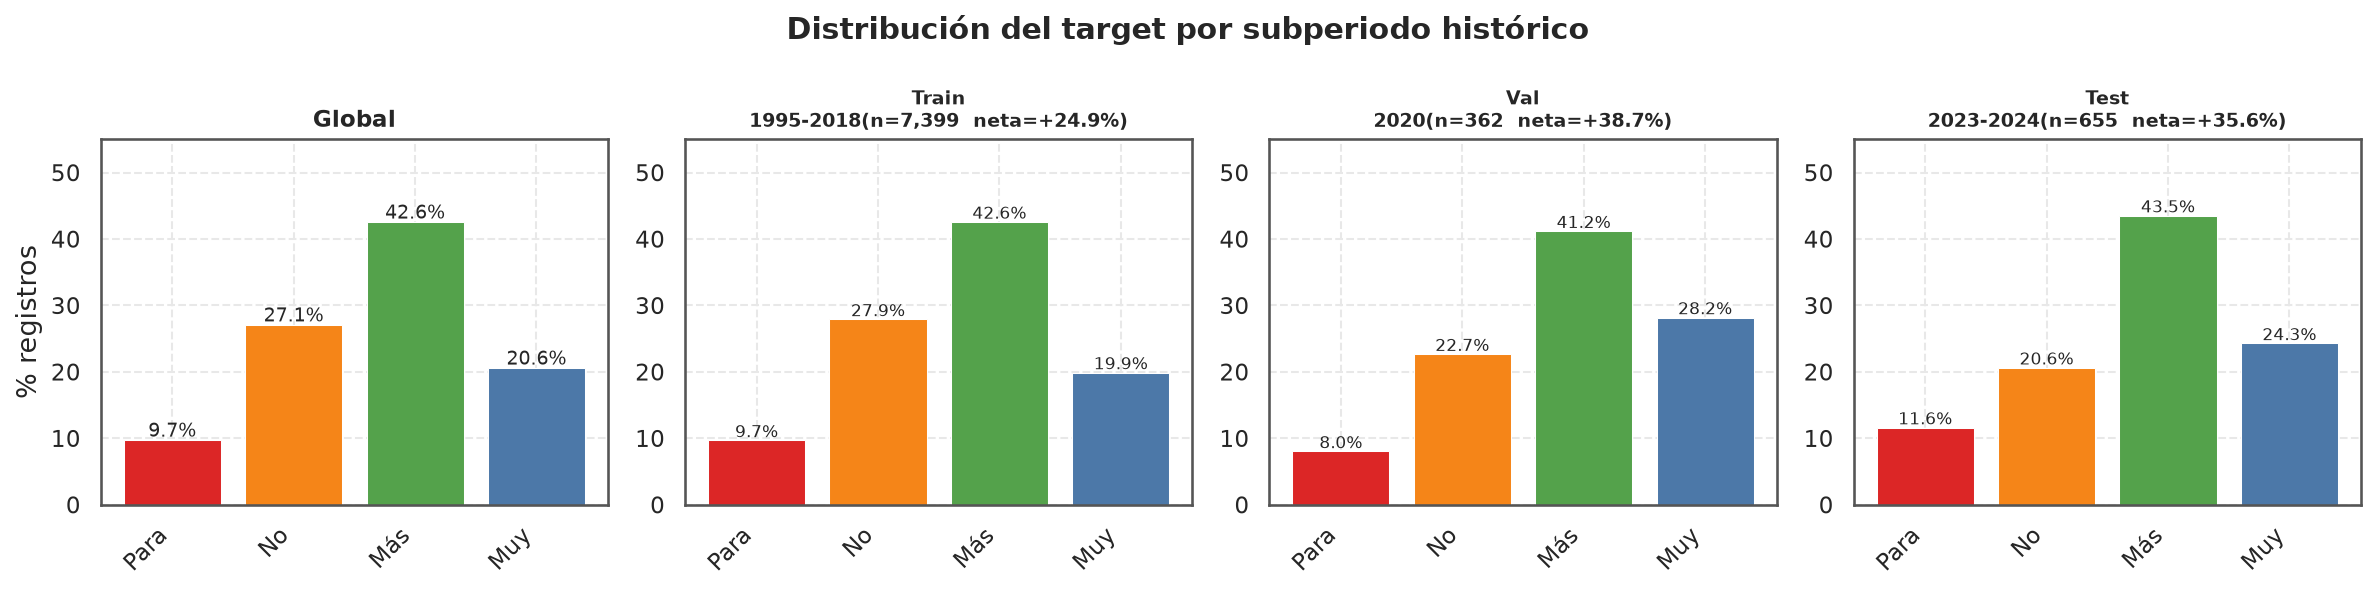

✓ Figura guardada: eda1_target_subperiodos.png


In [13]:
# =============================================================================
# EDA 1.1 — Distribución del target por conjunto (train / val / test)
# =============================================================================
# EDA 1.1 — Split único: Train / Validación / Test
SP_HIST = {
    "Train\n1995-2018": SPLIT["train"],
    "Val\n2020":        SPLIT["val"],
    "Test\n2023-2024":  SPLIT["test"],
}
colores_cls = [THEME["target"][i] for i in range(4)]

fig, axes = plt.subplots(1, len(SP_HIST) + 1, figsize=(16, 4))

# Panel global
ax = axes[0]
vals_g = df[COL_TARGET].value_counts(normalize=True).sort_index() * 100
etiq_cortas = [v.split()[0] for v in ETIQUETAS.values()]
ax.bar(etiq_cortas, vals_g.values, color=colores_cls, edgecolor="white", linewidth=0.5)
ax.set_title("Global", fontweight="bold", fontsize=11)
ax.set_ylabel("% registros")
ax.set_ylim(0, 55)
for i, v in enumerate(vals_g.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

# Paneles por subperiodo
for ax, (sp_label, años) in zip(axes[1:], SP_HIST.items()):
    sub  = df[df[COL_AÑO].isin(años)]
    vals = sub[COL_TARGET].value_counts(normalize=True).sort_index() * 100
    neta = (vals.get(2, 0) + vals.get(3, 0)) - (vals.get(0, 0) + vals.get(1, 0))
    bars = [vals.get(i, 0) for i in range(4)]
    ax.bar(etiq_cortas, bars, color=colores_cls, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{sp_label}(n={len(sub):,}  neta={neta:+.1f}%)",
                 fontsize=9, fontweight="bold")
    ax.set_ylim(0, 55)
    for i, v in enumerate(bars):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=8)

fig.suptitle("Distribución del target por subperiodo histórico", fontweight="bold")
for ax in axes:
    ax.tick_params(axis="x", labelrotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")
save_figure("eda1_target_subperiodos")
plt.show()
print("✓ Figura guardada: eda1_target_subperiodos.png")

  ✓ Figura guardada: eda1_missingness_heatmap.png


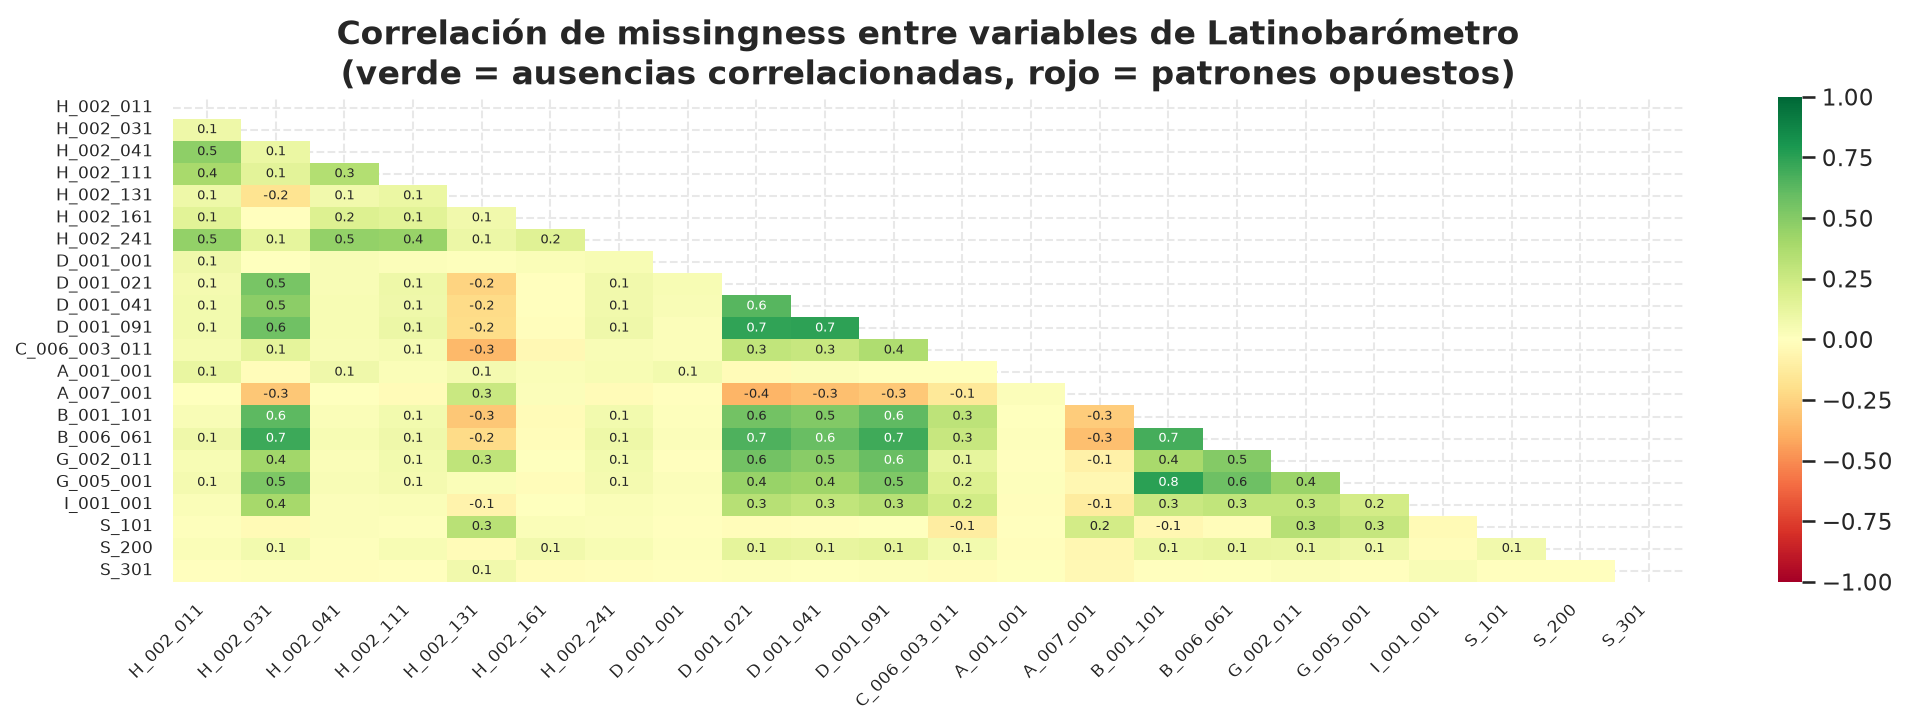

Cobertura por variable (% de valores válidos):
  Variable                  Etiqueta                         Bloque                         Cobertura
  ───────────────────────────────────────────────────────────────────────────────────────────────
  H_002_011                 Confianza Congreso               Confianza institucional         96.5%
  H_002_031                 Confianza Gobierno               Confianza institucional         82.0%
  H_002_041                 Confianza Poder Judicial         Confianza institucional         97.1%
  H_002_111                 Confianza Policía                Confianza institucional         98.6%
  H_002_131                 Confianza Televisión             Confianza institucional         77.1%
  H_002_161                 Confianza FF.AA.                 Confianza institucional         88.2%
  H_002_241                 Confianza Partidos Políticos     Confianza institucional         97.7%
  D_001_001                 Situación económica país        

In [14]:
# =============================================================================
# EDA 1.2 — Heatmap de missingness y tabla de cobertura por variable
# =============================================================================
# Solo las features del modelo (sin columnas de metadata)
FEATURES_EDA = []
for bloque, variables in BLOQUES.items():
    if "V-Dem" not in bloque:   # LB features
        FEATURES_EDA.extend([v for v in variables if v in df.columns])
FEATURES_EDA = list(dict.fromkeys(FEATURES_EDA))  # sin duplicados

fig, ax = plt.subplots(figsize=(14, 5))
msno.heatmap(df[FEATURES_EDA], ax=ax, fontsize=8, cmap="RdYlGn",
             labels=[ETIQUETAS_FEATURES.get(c, c) for c in FEATURES_EDA])
ax.set_title("Correlación de missingness entre variables de Latinobarómetro\n"
             "(verde = ausencias correlacionadas, rojo = patrones opuestos)",
             fontweight="bold")
save_figure("eda1_missingness_heatmap")
plt.show()

# Tabla de cobertura
print("Cobertura por variable (% de valores válidos):")
print(f"  {'Variable':<25} {'Etiqueta':<32} {'Bloque':<30} {'Cobertura'}")
print("  " + "─" * 95)
for col in FEATURES_EDA:
    cob = (1 - df[col].isnull().mean()) * 100
    et  = ETIQUETAS_FEATURES.get(col, col)
    bl  = bloque_de(col)
    print(f"  {col:<25} {et:<32} {bl:<30} {cob:>5.1f}%")

  ✓ Figura guardada: eda1_missingness_por_split.png


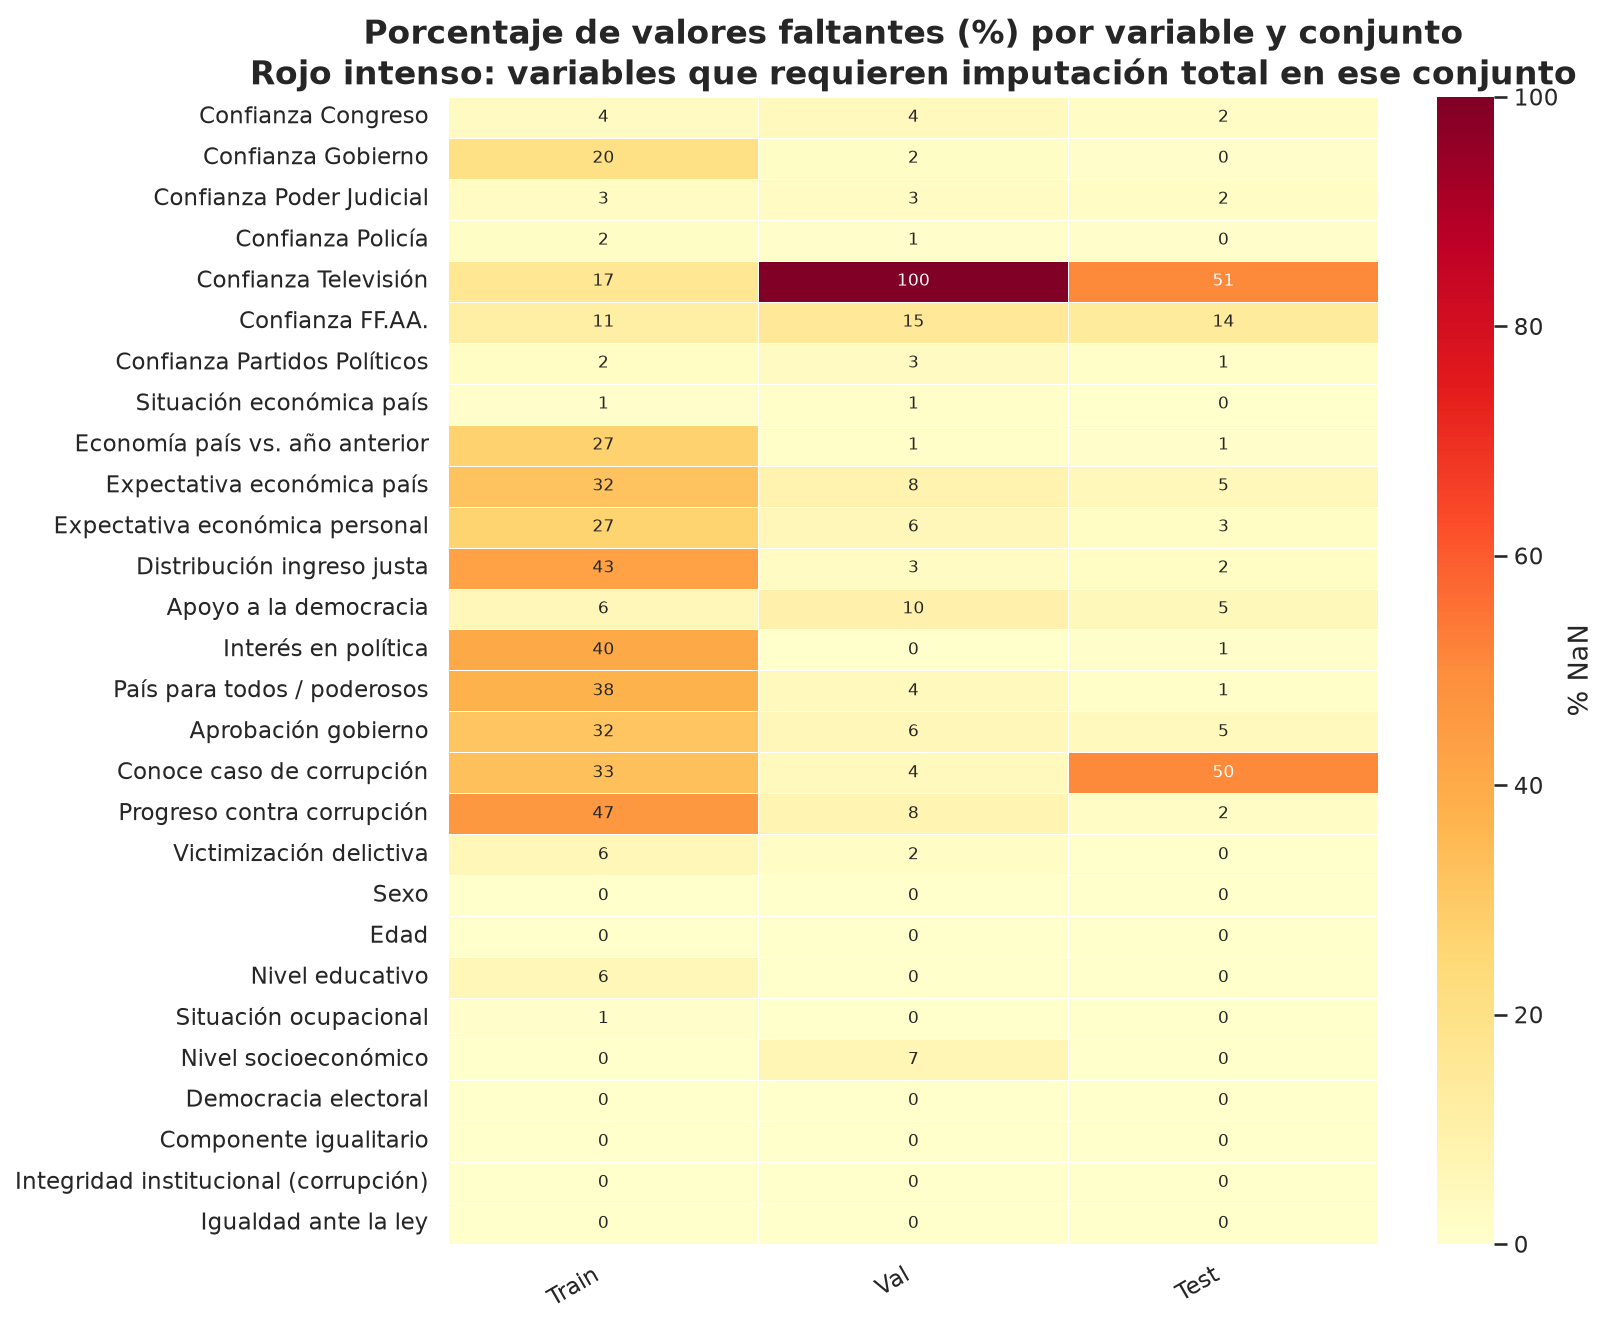

Variables con 100% de faltantes en algún conjunto de prueba:
  H_002_131 (Confianza Televisión): 100% NaN en ['Val']
  (Estas variables se imputan completamente con la media/moda del train)


In [15]:
# =============================================================================
# EDA 1.3 — Missingness por variable y por split (train/test de cada SP)
# =============================================================================
# Missingness por conjunto del split único
SP_SPLITS = {
    "Train"    : SPLIT["train"],
    "Val"      : SPLIT["val"],
    "Test"     : SPLIT["test"],
}

miss_sp = {}
for sp_name, años in SP_SPLITS.items():
    sub = df[df[COL_AÑO].isin(años)][FEATURES_EDA]
    miss_sp[sp_name] = (sub.isnull().mean() * 100).round(1)

df_miss_sp = pd.DataFrame(miss_sp)
# Etiquetas cortas para el eje Y
df_miss_sp.index = [ETIQUETAS_FEATURES.get(c, c) for c in FEATURES_EDA]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df_miss_sp, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.3, ax=ax, cbar_kws={"label": "% NaN"},
            annot_kws={"size": 8})
ax.set_title("Porcentaje de valores faltantes (%) por variable y conjunto\n"
             "Rojo intenso: variables que requieren imputación total en ese conjunto",
             fontweight="bold")
plt.xticks(rotation=30, ha="right")
save_figure("eda1_missingness_por_split")
plt.show()

# Alertas
print("Variables con 100% de faltantes en algún conjunto de prueba:")
df_miss_sp_orig = pd.DataFrame(miss_sp)  # con índice original para la búsqueda
for col in FEATURES_EDA:
    et = ETIQUETAS_FEATURES.get(col, col)
    tests_100 = [sp for sp in ["Val","Test"]
                 if df_miss_sp_orig.loc[col, sp] == 100.0]
    if tests_100:
        print(f"  {col} ({et}): 100% NaN en {tests_100}")
print("  (Estas variables se imputan completamente con la media/moda del train)")

## EDA 1.4 — Tratamiento de casos especiales: Venezuela y Nicaragua

In [16]:
# =============================================================================
# EDA 1.4 — Cobertura y justificación del tratamiento de Venezuela y Nicaragua
# Los valores de esta celda se usan directamente en el Cap. 4 de la tesis.
# Guardar en: results/tables/eda_venezuela_nicaragua.csv
# =============================================================================
from scipy import stats as _stats

print("=" * 65)
print("VENEZUELA — justificación del corte en 2017")
print("=" * 65)

ven_data = []
for año in sorted(df[df[COL_PAIS]=="Venezuela"][COL_AÑO].unique()):
    sub_ven = df[(df[COL_PAIS]=="Venezuela") & (df[COL_AÑO]==año)][COL_TARGET].dropna()
    sub_otros = df[(df[COL_PAIS]!="Venezuela") & (df[COL_AÑO]==año)][COL_TARGET].dropna()
    if len(sub_ven) == 0 or len(sub_otros) == 0:
        continue
    ks_stat, ks_p = _stats.ks_2samp(sub_ven, sub_otros)
    pct_clase3 = (sub_ven == 3).mean() * 100
    anomalia = "⚠ ANOMALÍA" if ks_p < 0.05 else ""
    print(f"  {año}: n={len(sub_ven):>3}  %clase3={pct_clase3:>5.1f}%  "
          f"KS p={ks_p:.3f}  {anomalia}")
    ven_data.append({"año":año, "n_ven":len(sub_ven), "pct_clase3":round(pct_clase3,1),
                     "ks_stat":round(ks_stat,4), "ks_p":round(ks_p,4),
                     "anomalia": ks_p < 0.05})

df_ven = pd.DataFrame(ven_data)
print()
print("Conclusión:")
print("  - 2017: KS p={:.3f} (NO significativo → datos aún representativos)".format(
    df_ven[df_ven["año"]==2017]["ks_p"].values[0] if 2017 in df_ven["año"].values else float("nan")))
print("  - 2018: KS p={:.3f} (significativo → inicio del sesgo)".format(
    df_ven[df_ven["año"]==2018]["ks_p"].values[0] if 2018 in df_ven["año"].values else float("nan")))
print("  Corte adoptado: AÑO_CORTE_VEN = 2017")
print()

print("=" * 65)
print("NICARAGUA — cobertura en el dataset")
print("=" * 65)

años_nic = sorted(df[df[COL_PAIS]=="Nicaragua"][COL_AÑO].unique())
print(f"  Años con datos: {años_nic}")
print(f"  Ausente en 2023 y 2024 (años del test) → exclusión automática del test")
nic_2020 = df[(df[COL_PAIS]=="Nicaragua") & (df[COL_AÑO]==2020)][COL_TARGET].dropna()
otros_2020 = df[(df[COL_PAIS]!="Nicaragua") & (df[COL_AÑO]==2020)][COL_TARGET].dropna()
if len(nic_2020) > 0 and len(otros_2020) > 0:
    ks_nic, p_nic = _stats.ks_2samp(nic_2020, otros_2020)
    print(f"  KS(Nicaragua 2020, otros 2020): stat={ks_nic:.4f}, p={p_nic:.4f}")
    print(f"  Excluida de validación por consistencia de dominio con el test")

# Guardar tabla para la tesis
PATHS["FOLDER_RESULTS_TABLES"].mkdir(parents=True, exist_ok=True)
df_ven.to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "eda_venezuela_anomalia.csv", index=False)
print()
print(f"✓ Tabla guardada: results/tables/eda_venezuela_anomalia.csv")
print("  → Usar en Cap. 4, sección de exclusiones y casos especiales")


VENEZUELA — justificación del corte en 2017
  1995: n= 23  %clase3= 30.4%  KS p=0.576  
  1996: n= 23  %clase3= 30.4%  KS p=0.999  
  1997: n= 18  %clase3= 22.2%  KS p=0.935  
  1998: n= 18  %clase3= 27.8%  KS p=1.000  
  2000: n= 24  %clase3= 12.5%  KS p=0.162  
  2001: n= 20  %clase3= 15.0%  KS p=0.622  
  2002: n= 19  %clase3= 26.3%  KS p=0.758  
  2003: n= 19  %clase3= 21.1%  KS p=0.361  
  2004: n= 22  %clase3= 13.6%  KS p=0.777  
  2005: n= 24  %clase3= 12.5%  KS p=0.097  
  2006: n= 24  %clase3= 16.7%  KS p=0.016  ⚠ ANOMALÍA
  2007: n= 18  %clase3=  5.6%  KS p=0.000  ⚠ ANOMALÍA
  2008: n= 24  %clase3= 29.2%  KS p=0.997  
  2009: n= 19  %clase3= 21.1%  KS p=0.974  
  2010: n= 20  %clase3= 30.0%  KS p=0.686  
  2011: n= 22  %clase3=  9.1%  KS p=0.537  
  2013: n= 25  %clase3= 12.0%  KS p=0.749  
  2015: n= 24  %clase3= 29.2%  KS p=0.819  
  2016: n= 24  %clase3= 50.0%  KS p=0.035  ⚠ ANOMALÍA
  2017: n= 19  %clase3= 47.4%  KS p=0.163  

Conclusión:
  - 2017: KS p=0.163 (NO signific

## EDA 1.5 — Correlación Spearman: año vs. target

In [17]:
# =============================================================================
# EDA 1.5 — Correlación Spearman entre año de encuesta y target
# Justifica por qué el año NO se incluye como feature predictivo.
# Guardar en: results/tables/eda_correlacion_año_target.csv
# =============================================================================
from scipy import stats as _stats

mask_corr = df[COL_TARGET].notna() & df[COL_AÑO].notna()
r_año, p_año = _stats.spearmanr(df.loc[mask_corr, COL_AÑO],
                                  df.loc[mask_corr, COL_TARGET])
n_año = mask_corr.sum()

print("Correlación Spearman: año vs. target")
print(f"  r = {r_año:.4f}")
print(f"  p = {p_año:.4f}")
print(f"  n = {n_año:,}")
print()
print("Interpretación:")
print(f"  |r| = {abs(r_año):.4f} → correlación MUY BAJA")
print("  El año de la encuesta tiene mínima señal predictiva sobre la")
print("  satisfacción democrática. Sin embargo, el año es INDISPENSABLE")
print("  como criterio de partición temporal para evitar data leakage.")
print("  Incluirlo como feature aportaría ruido sin señal predictiva.")
print()

# Guardar
import pandas as _pd
_pd.DataFrame([{
    "variable": "año", "r_spearman": round(r_año, 4),
    "p_valor": round(p_año, 4), "n": n_año,
    "interpretacion": "Señal baja — no se incluye como feature"
}]).to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "eda_correlacion_año_target.csv", index=False)
print("✓ Guardado: results/tables/eda_correlacion_año_target.csv")
print("  → Usar en Cap. 4, sección 3.3 del documento metodológico")


Correlación Spearman: año vs. target
  r = 0.0172
  p = 0.1140
  n = 8,416

Interpretación:
  |r| = 0.0172 → correlación MUY BAJA
  El año de la encuesta tiene mínima señal predictiva sobre la
  satisfacción democrática. Sin embargo, el año es INDISPENSABLE
  como criterio de partición temporal para evitar data leakage.
  Incluirlo como feature aportaría ruido sin señal predictiva.

✓ Guardado: results/tables/eda_correlacion_año_target.csv
  → Usar en Cap. 4, sección 3.3 del documento metodológico


## EDA 1.6 — Correlaciones Spearman: features LB y V-Dem vs. target

In [18]:
# =============================================================================
# EDA 1.6 — Correlaciones Spearman: todas las features vs. target
# Calculadas sobre el TRAIN del split único.
# Guardar en: results/tables/eda_correlaciones_features.csv
# =============================================================================
from scipy import stats as _stats

df_train = df[df[COL_AÑO].isin(SPLIT["train"])].copy()
# Venezuela: solo hasta 2017
df_train = df_train[~((df_train[COL_PAIS]=="Venezuela") & (df_train[COL_AÑO]>AÑO_CORTE_VEN))]

# Construir la lista de features desde BLOQUES (disponible desde config.py,
# no depende de la celda de features que viene más adelante en el notebook)
_feats_eda = []
for _bloque in BLOQUES:
    _feats_eda.extend([c for c in BLOQUES[_bloque] if c in df_train.columns])

# V-Dem: nivel país-año (agregar por país-año para mayor limpieza)
df_py = df_train.groupby([COL_ISO3, COL_AÑO]).agg(
    target_mean=(COL_TARGET, "mean")).reset_index()
df_py = df_py.merge(
    df_train[[COL_ISO3, COL_AÑO] + [c for c in _feats_eda if c.startswith("v2")]].drop_duplicates(),
    on=[COL_ISO3, COL_AÑO], how="left")

resultados = []
vdem_vars = [c for c in _feats_eda if c.startswith("v2")]
lb_vars   = [c for c in _feats_eda if not c.startswith("v2")]

print(f"{'Feature':<22} {'Tipo':<8} {'r ind.':>8} {'p ind.':>8} {'Señal'}")
print("─" * 60)
for feat in lb_vars + vdem_vars:
    if feat not in df_train.columns:
        continue
    tipo = "V-Dem" if feat.startswith("v2") else "LB"

    # Correlación individual
    x = pd.to_numeric(df_train[feat], errors="coerce")
    mask = x.notna() & df_train[COL_TARGET].notna()
    if mask.sum() < 50:
        continue
    r_ind, p_ind = _stats.spearmanr(x[mask], df_train.loc[mask, COL_TARGET])

    # Correlación país-año (solo para V-Dem)
    r_pa = np.nan
    if tipo == "V-Dem" and feat in df_py.columns:
        mask_pa = df_py[feat].notna() & df_py["target_mean"].notna()
        if mask_pa.sum() > 20:
            r_pa, _ = _stats.spearmanr(df_py.loc[mask_pa, feat],
                                         df_py.loc[mask_pa, "target_mean"])

    señal = "ALTA" if abs(r_ind) >= 0.10 else ("MEDIA" if abs(r_ind) >= 0.05 else "BAJA")
    etiq = ETIQUETAS_FEATURES.get(feat, feat)
    print(f"  {feat:<20} {tipo:<8} {r_ind:>+8.4f} {p_ind:>8.4f} {señal}  {etiq}")
    resultados.append({"variable":feat, "tipo":tipo, "bloque":bloque_de(feat),
                        "etiqueta":etiq, "r_individual":round(r_ind,4),
                        "p_individual":round(p_ind,4), "r_pais_año":round(r_pa,4) if not np.isnan(r_pa) else None,
                        "señal":señal})

df_corr = pd.DataFrame(resultados).sort_values("r_individual", key=abs, ascending=False)
df_corr.to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "eda_correlaciones_features.csv", index=False)
print()
print(f"✓ Guardado: results/tables/eda_correlaciones_features.csv ({len(df_corr)} filas)")
print("  → Usar en Cap. 4, Tablas de selección de variables")
print()
print("HALLAZGO V-DEM: correlaciones negativas con calidad democrática")
print("  Interpretación: ciudadanos más exigentes en democracias más avanzadas")
print("  (Norris, 2011 — Critical Citizens)")
print("  → Nuevo H5 de la tesis")


Feature                Tipo       r ind.   p ind. Señal
────────────────────────────────────────────────────────────
  H_002_011            LB        +0.2989   0.0000 ALTA  Confianza Congreso
  H_002_031            LB        +0.3712   0.0000 ALTA  Confianza Gobierno
  H_002_041            LB        +0.2824   0.0000 ALTA  Confianza Poder Judicial
  H_002_111            LB        +0.2376   0.0000 ALTA  Confianza Policía
  H_002_131            LB        +0.1355   0.0000 ALTA  Confianza Televisión
  H_002_161            LB        +0.1797   0.0000 ALTA  Confianza FF.AA.
  H_002_241            LB        +0.2504   0.0000 ALTA  Confianza Partidos Políticos
  D_001_001            LB        +0.3155   0.0000 ALTA  Situación económica país
  D_001_021            LB        -0.2837   0.0000 ALTA  Economía país vs. año anterior
  D_001_041            LB        -0.2798   0.0000 ALTA  Expectativa económica país
  D_001_091            LB        -0.1675   0.0000 ALTA  Expectativa económica personal
  C_0

## EDA 1.7 — Desbalance de clases por conjunto

Conjunto        N total    Cls0   Cls1   Cls2   Cls3   Ratio
──────────────────────────────────────────────────────────────────────


  Train           7,399    9.7%  27.9%  42.6%  19.9%    4.4x
  Validación        341    7.3%  22.0%  42.5%  28.2%    5.8x
  Test              655   11.6%  20.6%  43.5%  24.3%    3.8x

KS(val, test): estadístico=0.0427, p=0.7865
  → Sin diferencia significativa
  Interpretar: val representa el mismo dominio que test

Predictor trivial (siempre clase 2):
  Accuracy trivial sobre test: 43.5%
  Kappa cuadrático trivial: ~0.00 (por definición)


  ✓ Figura guardada: 02_eda_desbalance_clases.png


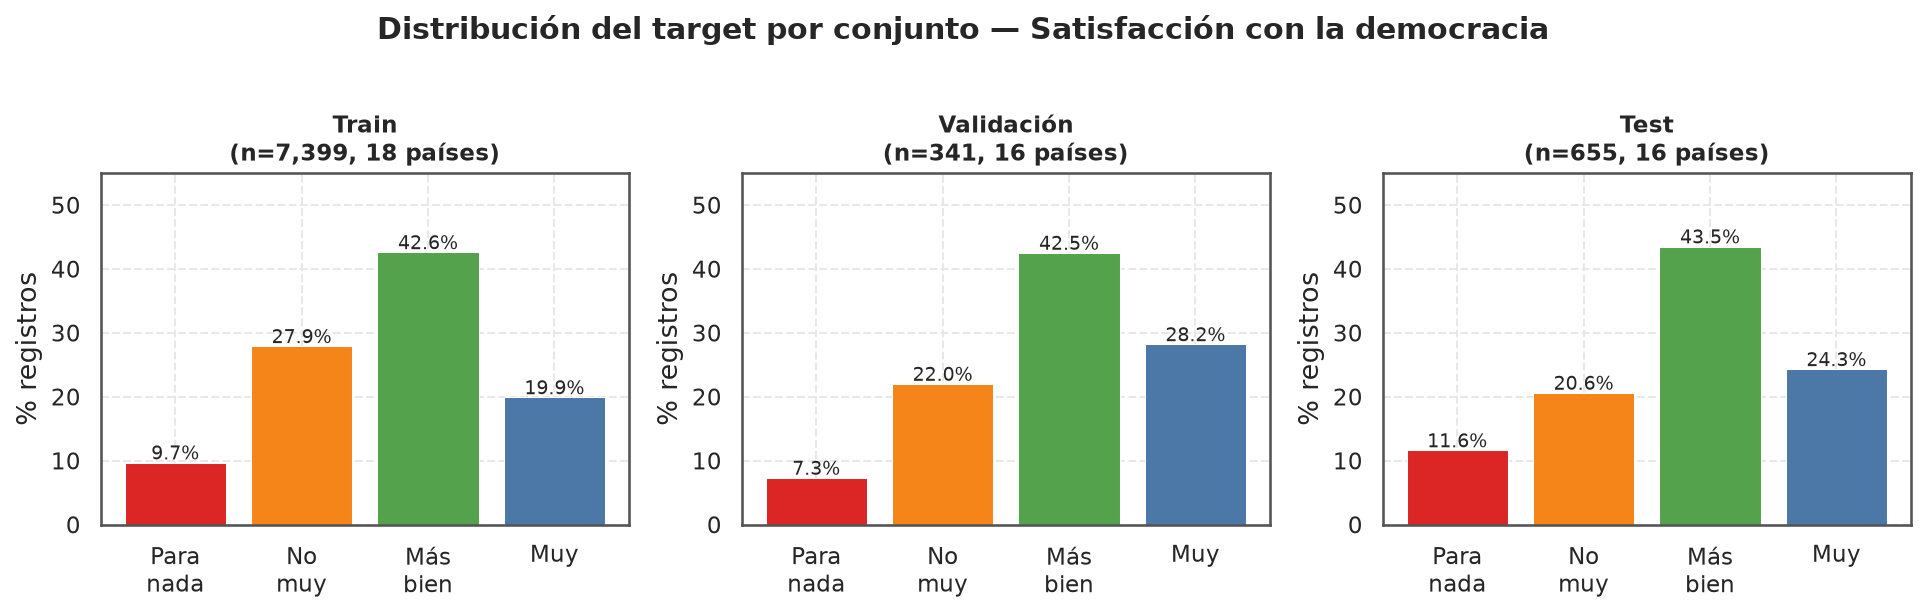

✓ Figura: results/figures/02_eda_desbalance_clases.png
✓ Tabla:  results/tables/eda_desbalance_clases.csv
  → Usar en Cap. 4, Tabla 4.X — Distribución del target por conjunto


In [19]:
# =============================================================================
# EDA 1.7 — Distribución del target por conjunto (train / val / test)
# Documenta el desbalance real para el documento de tesis.
# Guardar en: results/tables/eda_desbalance_clases.csv
# =============================================================================
from scipy import stats as _stats

# Excluir Venezuela y Nicaragua de val y test (igual que construir_split)
df_train_ = df[df[COL_AÑO].isin(SPLIT["train"])].copy()
df_train_ = df_train_[~((df_train_[COL_PAIS]=="Venezuela") & (df_train_[COL_AÑO]>AÑO_CORTE_VEN))]
df_val_   = df[df[COL_AÑO].isin(SPLIT["val"])].copy()
df_val_   = df_val_[~df_val_[COL_PAIS].isin(PAISES_EXCLUIR_EVAL)]
df_test_  = df[df[COL_AÑO].isin(SPLIT["test"])].copy()
df_test_  = df_test_[~df_test_[COL_PAIS].isin(PAISES_EXCLUIR_EVAL)]

print(f"{'Conjunto':<12} {'N total':>10}  {'Cls0':>6} {'Cls1':>6} {'Cls2':>6} {'Cls3':>6}  {'Ratio':>6}")
print("─" * 70)

filas = []
for nombre, sub_df in [("Train", df_train_), ("Validación", df_val_), ("Test", df_test_)]:
    y = sub_df[COL_TARGET].dropna()
    if len(y) == 0:
        continue
    dist = y.value_counts(normalize=True).sort_index() * 100
    ratio = dist.max() / dist.min() if dist.min() > 0 else float("inf")
    n_paises = sub_df[COL_PAIS].nunique()
    print(f"  {nombre:<10} {len(y):>10,}  "
          f"{dist.get(0.0,0):>5.1f}% {dist.get(1.0,0):>5.1f}% "
          f"{dist.get(2.0,0):>5.1f}% {dist.get(3.0,0):>5.1f}%  {ratio:>5.1f}x")
    filas.append({"conjunto":nombre, "n":len(y), "n_paises":n_paises,
                  "pct_cls0":round(dist.get(0.0,0),1), "pct_cls1":round(dist.get(1.0,0),1),
                  "pct_cls2":round(dist.get(2.0,0),1), "pct_cls3":round(dist.get(3.0,0),1),
                  "ratio_desbalance":round(ratio,2)})

# Test KS validación vs. test
y_val_ = df_val_[COL_TARGET].dropna()
y_te_  = df_test_[COL_TARGET].dropna()
ks_vt, p_vt = _stats.ks_2samp(y_val_, y_te_)
print()
print(f"KS(val, test): estadístico={ks_vt:.4f}, p={p_vt:.4f}")
print(f"  → {'Sin diferencia significativa' if p_vt>0.05 else 'DIFERENCIA SIGNIFICATIVA'}")
print(f"  Interpretar: val representa el mismo dominio que test")
print()
print("Predictor trivial (siempre clase 2):")
n_total = sum(f["n"] for f in filas if f["conjunto"]=="Test")
if n_total > 0:
    acc_trivial = filas[-1]["pct_cls2"] / 100
    print(f"  Accuracy trivial sobre test: {acc_trivial:.1%}")
    print(f"  Kappa cuadrático trivial: ~0.00 (por definición)")

# Figura
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colores_cls = [THEME["target"][i] for i in range(4)]
etiq_cortas = ["Para\nnada", "No\nmuy", "Más\nbien", "Muy"]

for ax, fila in zip(axes, filas):
    vals = [fila[f"pct_cls{i}"] for i in range(4)]
    bars = ax.bar(etiq_cortas, vals, color=colores_cls, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{fila['conjunto']}\n(n={fila['n']:,}, {fila['n_paises']} países)",
                 fontweight="bold", fontsize=11)
    ax.set_ylabel("% registros")
    ax.set_ylim(0, 55)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

plt.suptitle("Distribución del target por conjunto — Satisfacción con la democracia",
             fontweight="bold", y=1.02)
plt.tight_layout()
from utils.plots import save_figure
save_figure("02_eda_desbalance_clases")
plt.show()

pd.DataFrame(filas).to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "eda_desbalance_clases.csv", index=False)
print("✓ Figura: results/figures/02_eda_desbalance_clases.png")
print("✓ Tabla:  results/tables/eda_desbalance_clases.csv")
print("  → Usar en Cap. 4, Tabla 4.X — Distribución del target por conjunto")


## 9. Definición del conjunto de features por modelo

Los índices V-Dem se diferencian por tipo de modelo:
- **OLO (baseline)**: recibe los 5 índices de alto nivel, que representan
  la práctica estándar en ciencias políticas cuantitativas. Los índices
  de nivel medio presentan correlaciones de 0.70–0.97 entre sí, lo que
  generaría estimaciones inestables en la regresión logística.
- **Árboles y TabNet**: reciben los 14 índices de nivel medio más
  `v2x_polyarchy`, que aporta la dimensión democrática agregada y
  mejora la comparabilidad directa con OLO.

In [20]:
# =============================================================================
# Conjunto único de features (28 variables)
# OLO, XGBoost, CatBoost, LightGBM y TabNet reciben el mismo conjunto.
# Los 5 bloques LB (24 vars) + 1 bloque V-Dem (4 vars) = 28 features.
# =============================================================================

# Construir lista ordenada por bloque
FEATURES = []
for bloque in BLOQUES:
    FEATURES.extend([c for c in BLOQUES[bloque] if c in df.columns])

VARS_CAT = [c for c in VARS_CATEGORICAS if c in df.columns]

print(f"Total features: {len(FEATURES)}")
print()
print("Distribución por bloque temático:")
for bloque, variables in BLOQUES.items():
    presentes = [v for v in variables if v in df.columns]
    print(f"  {bloque:<40}: {len(presentes)} variables  {presentes}")
print()
print(f"Variables categóricas (para CatBoost): {VARS_CAT}")
print()
# Verificar que no haya duplicados
assert len(FEATURES) == len(set(FEATURES)), f"Duplicados en FEATURES: {[f for f in FEATURES if FEATURES.count(f)>1]}"
print(f"✓ Sin duplicados en la lista de features")

Total features: 28

Distribución por bloque temático:
  Confianza institucional                 : 7 variables  ['H_002_011', 'H_002_031', 'H_002_041', 'H_002_111', 'H_002_131', 'H_002_161', 'H_002_241']
  Evaluación económica                    : 5 variables  ['D_001_001', 'D_001_021', 'D_001_041', 'D_001_091', 'C_006_003_011']
  Percepción política                     : 4 variables  ['A_001_001', 'A_007_001', 'B_001_101', 'B_006_061']
  Corrupción y seguridad                  : 3 variables  ['G_002_011', 'G_005_001', 'I_001_001']
  Características sociodemográficas       : 5 variables  ['S_001', 'S_002', 'S_101', 'S_200', 'S_301']
  Contexto democrático                    : 4 variables  ['v2x_polyarchy', 'v2x_egal', 'v2x_corr', 'v2xcl_rol']

Variables categóricas (para CatBoost): ['S_200']

✓ Sin duplicados en la lista de features


## EDA — Parte 2: Validación post-transformación y selección de features

Se verifica que las transformaciones produjeron la dirección esperada y se
realiza el análisis de correlación **por subperiodo histórico**, no global.

> **Criterio de selección:** una feature se documenta como sin aporte si
> no tiene señal estadísticamente significativa en **ningún** subperiodo
> ni en ninguna subregión, Y carece de justificación teórica sustantiva.
> La correlación global puede enmascarar señal real cuando las relaciones
> cambian de dirección entre períodos históricos.

  ✓ Figura guardada: eda2_distribuciones_post_transform.png


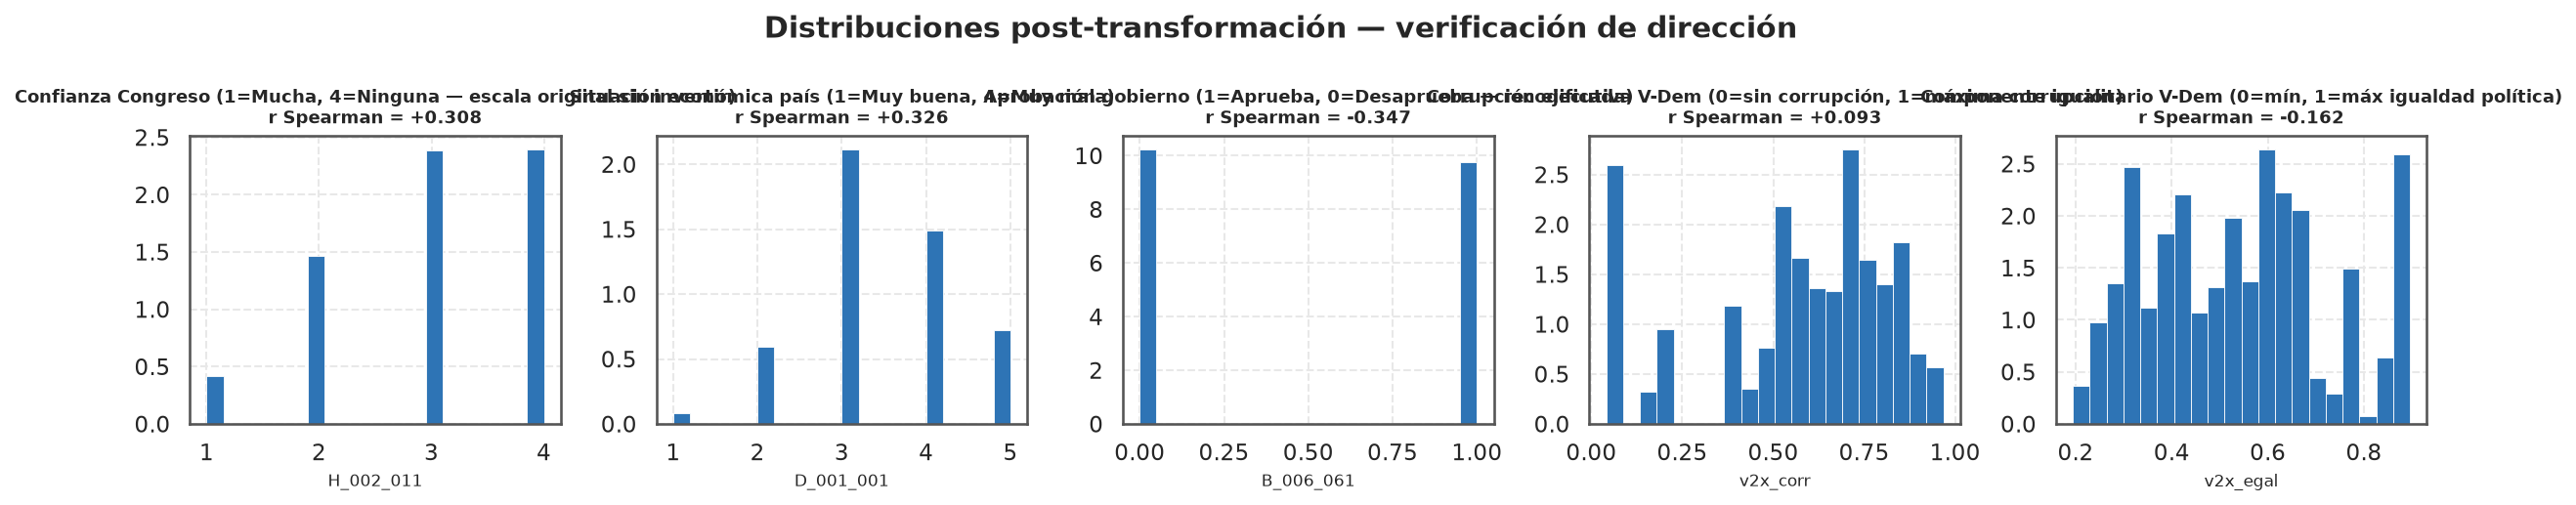

In [21]:
# =============================================================================
# EDA 2.1 — Verificación de inversiones: correlaciones post-transformación
# =============================================================================
VARS_VERIFICAR = {
    "H_002_011" : "Confianza Congreso (1=Mucha, 4=Ninguna — escala original sin invertir)",
    "D_001_001" : "Situación económica país (1=Muy buena, 4=Muy mala)",
    "B_006_061" : "Aprobación gobierno (1=Aprueba, 0=Desaprueba — recodificada)",
    "v2x_corr"  : "Corrupción ejecutiva V-Dem (0=sin corrupción, 1=máxima corrupción)",
    "v2x_egal"  : "Componente igualitario V-Dem (0=mín, 1=máx igualdad política)",
}

fig, axes = plt.subplots(1, len(VARS_VERIFICAR), figsize=(16, 3.5))
for ax, (col, titulo) in zip(axes, VARS_VERIFICAR.items()):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    x = pd.to_numeric(df[col], errors="coerce").dropna()
    y = df.loc[x.index, COL_TARGET]
    mask = y.notna()
    r, _ = stats.spearmanr(x[mask].values, y[mask].values)
    ax.hist(x.values, bins=20, color="#2E74B5", edgecolor="white",
            linewidth=0.4, density=True)
    ax.set_title(f"{titulo}\nr Spearman = {r:+.3f}", fontsize=8.5, fontweight="bold")
    ax.set_xlabel(col, fontsize=8)

fig.suptitle("Distribuciones post-transformación — verificación de dirección",
             fontweight="bold")
save_figure("eda2_distribuciones_post_transform")
plt.show()

In [22]:
# =============================================================================
# EDA 2.2 — Correlación de Spearman: features vs. target (conjunto train)
#
# La correlación se calcula sobre el conjunto TRAIN del split único para evitar
# cualquier contaminación del conjunto de test.
# =============================================================================
# Correlaciones calculadas sobre el train del split único
# (excluye val y test para evitar contaminación de información)
SP_TRAIN = {
    "Train": SPLIT["train"],
}

def corr_sp(feat, años):
    sub  = df[df[COL_AÑO].isin(años)].copy()
    x    = pd.to_numeric(sub[feat], errors="coerce")
    y    = sub[COL_TARGET]
    mask = x.notna() & y.notna()
    if mask.sum() < 50:
        return np.nan
    r, _ = stats.spearmanr(x[mask].values, y[mask].values)
    return r

print(f"{'Feature':<22} {'Etiqueta':<30} {'Bloque':<28} {'Train':>10}")
print("─" * 115)

REPORTE = {}
_lb_feats_eda = [c for bloque in BLOQUES
                   for c in BLOQUES[bloque]
                   if not c.startswith("v2") and c in df.columns]
for feat in _lb_feats_eda:
    if feat not in df.columns:
        continue
    rs     = {sp: corr_sp(feat, años) for sp, años in SP_TRAIN.items()}
    valid  = [r for r in rs.values() if not np.isnan(r)]
    max_sp = max(abs(r) for r in valid) if valid else 0
    signs  = [1 if r > 0.02 else (-1 if r < -0.02 else 0) for r in valid]
    inv    = len(set(s for s in signs if s != 0)) > 1
    REPORTE[feat] = {"rs": rs, "max_sp": max_sp, "inv": inv}

    et = ETIQUETAS_FEATURES.get(feat, feat)
    bl = bloque_de(feat)[:26]
    r1 = f"{rs.get('Train', float('nan')):+.3f}" if not np.isnan(rs.get("Train", float("nan"))) else "  NaN"
    r2 = f"{float('nan'):+.3f}" if not np.isnan(float('nan')) else "  NaN"
    r3 = f"{float('nan'):+.3f}" if not np.isnan(float('nan')) else "  NaN"
    inv_flag = " ↕" if inv else ""
    print(f"{feat:<22} {et:<30} {bl:<28} {rs.get('Train', float('nan')):>+10.4f}{inv_flag}")

print()
n_clara = sum(1 for v in REPORTE.values() if v["max_sp"] >= 0.05)
n_debil = sum(1 for v in REPORTE.values() if 0.02 <= v["max_sp"] < 0.05)
n_no    = sum(1 for v in REPORTE.values() if v["max_sp"] < 0.02)
print(f"Señal clara  (max|r|≥0.05): {n_clara} variables")
print(f"Señal débil  (max|r|≥0.02): {n_debil} variables")
print(f"Sin señal    (max|r|<0.02): {n_no} variables")
print()
print("↕ = la relación con el target cambia de signo entre subperiodos")
print("    (estas variables son especialmente relevantes para el análisis de estabilidad)")

Feature                Etiqueta                       Bloque                            Train
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
H_002_011              Confianza Congreso             Confianza institucional         +0.2989
H_002_031              Confianza Gobierno             Confianza institucional         +0.3712
H_002_041              Confianza Poder Judicial       Confianza institucional         +0.2824
H_002_111              Confianza Policía              Confianza institucional         +0.2376
H_002_131              Confianza Televisión           Confianza institucional         +0.1355
H_002_161              Confianza FF.AA.               Confianza institucional         +0.1797
H_002_241              Confianza Partidos Políticos   Confianza institucional         +0.2504
D_001_001              Situación económica país       Evaluación económica            +0.3155
D_001_021              Economía país v

S_301                  Nivel socioeconómico           Características sociodemog      +0.0217

Señal clara  (max|r|≥0.05): 19 variables
Señal débil  (max|r|≥0.02): 4 variables
Sin señal    (max|r|<0.02): 1 variables

↕ = la relación con el target cambia de signo entre subperiodos
    (estas variables son especialmente relevantes para el análisis de estabilidad)


  ✓ Figura guardada: eda2_correlaciones_subperiodo.png


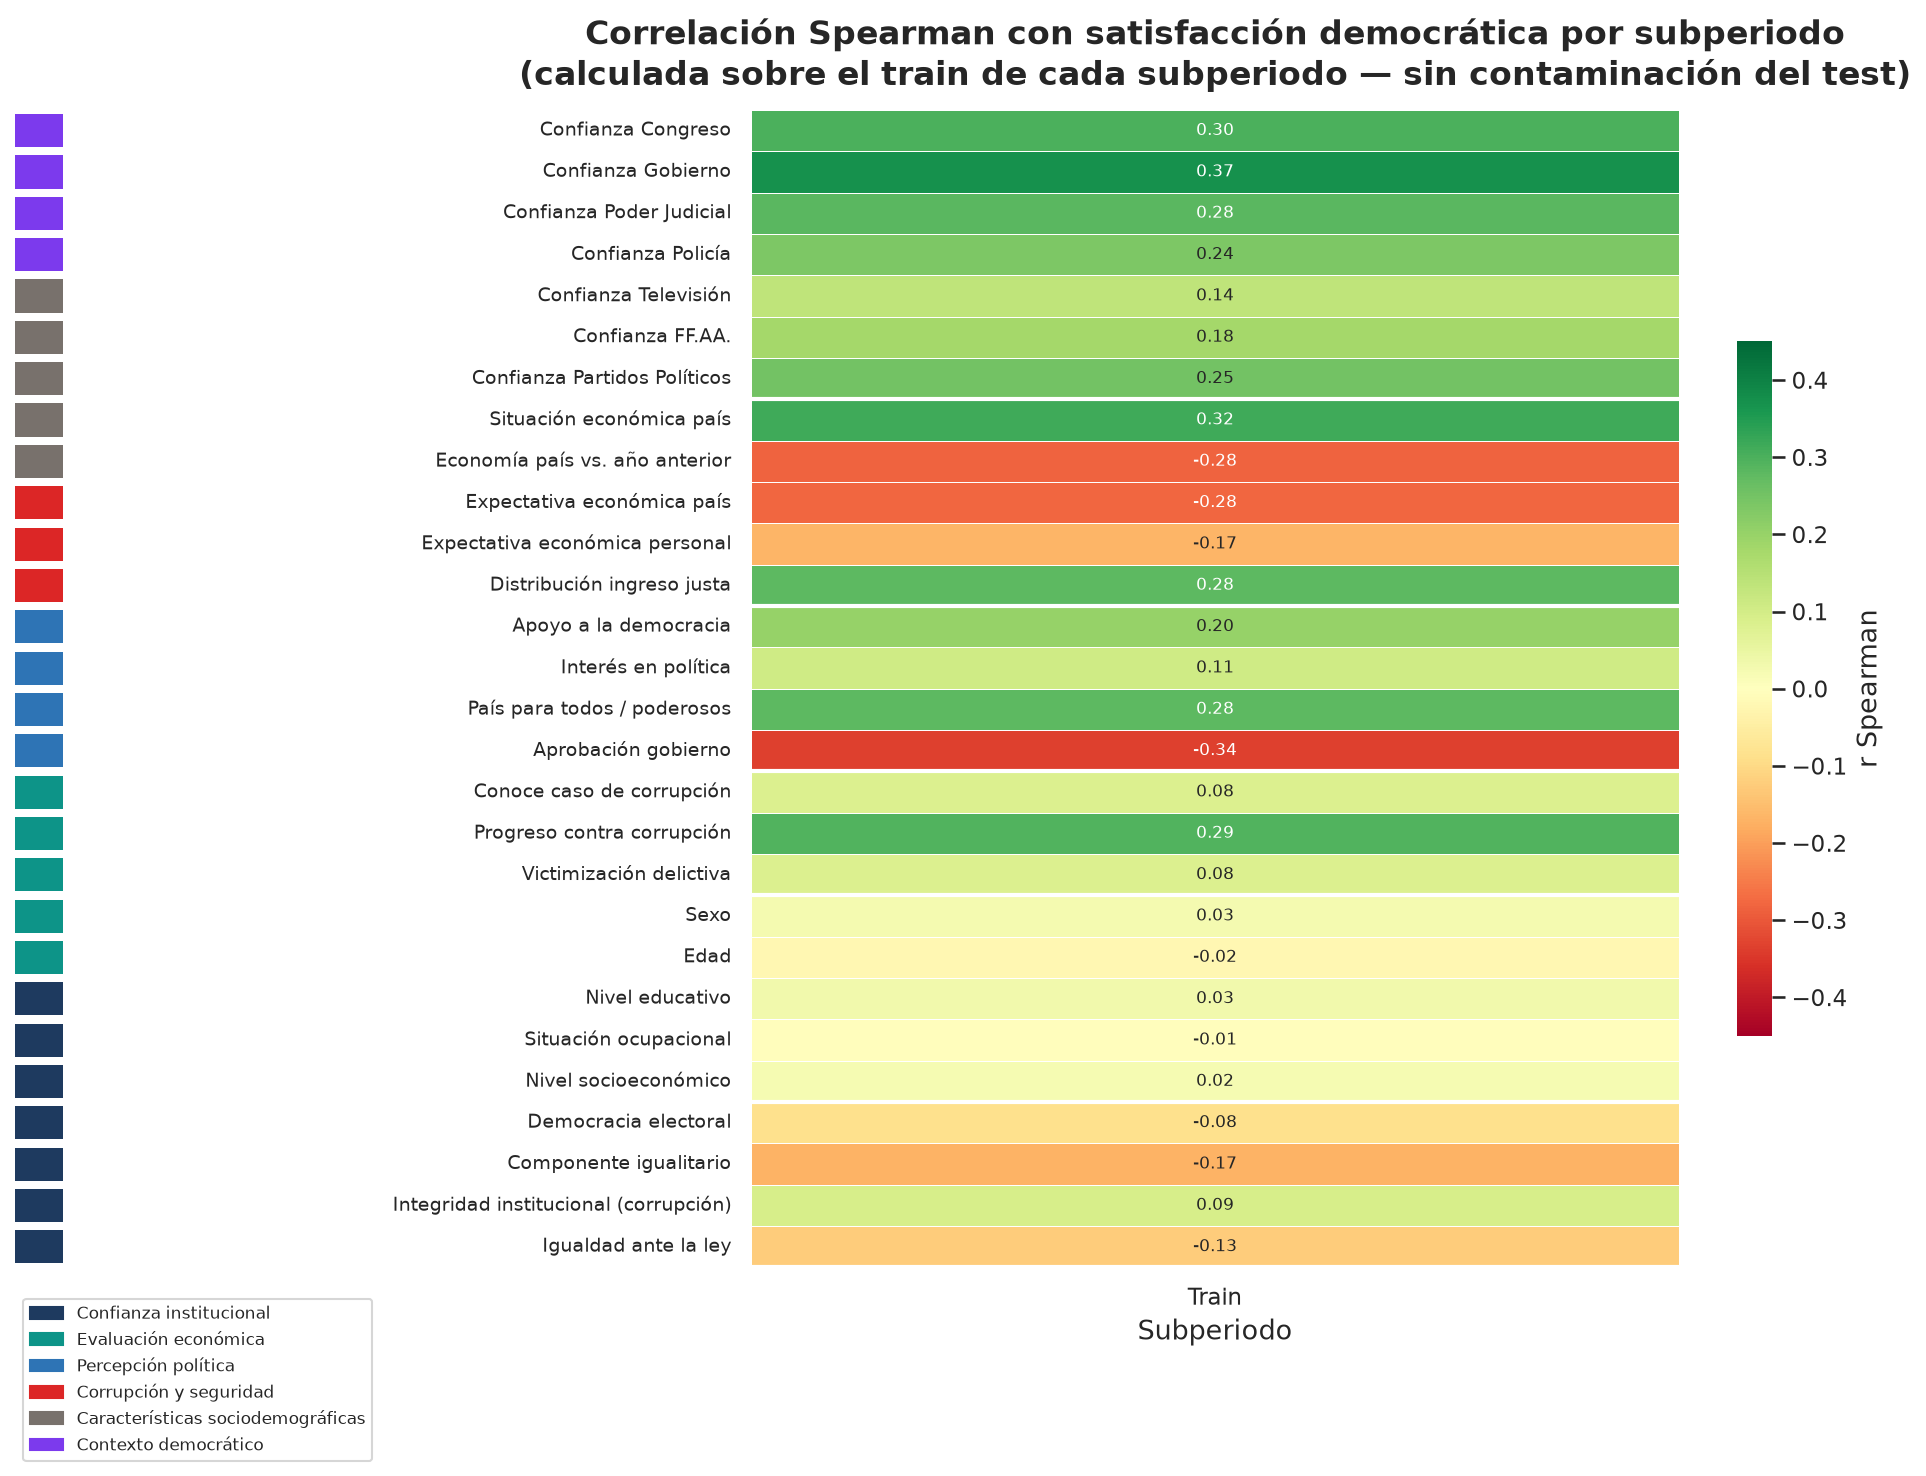

✓ Heatmap de correlaciones por subperiodo guardado


In [23]:
# =============================================================================
# EDA 2.3 — Heatmap de correlaciones Spearman, organizado por bloques temáticos
# =============================================================================
# Construir matriz de correlaciones con variables ordenadas por bloque temático
vars_ordenadas = []
bloques_labels = []
for bloque in THEME["blocks"]:
    for v in BLOQUES[bloque]:
        if v in df.columns:
            vars_ordenadas.append(v)
            bloques_labels.append(bloque)

# Calcular correlaciones para cada variable en el orden definido
rs_data = {}
for feat in vars_ordenadas:
    rs_data[feat] = {
        sp: corr_sp(feat, años) for sp, años in SP_TRAIN.items()
    }

df_rs = pd.DataFrame(rs_data, index=["Train"]).T
# Etiquetas cortas para eje Y
df_rs.index = [ETIQUETAS_FEATURES.get(c, c) for c in vars_ordenadas]

fig, (ax_bar, ax_heat) = plt.subplots(
    1, 2, figsize=(13, 10),
    gridspec_kw={"width_ratios": [0.04, 0.96]},
)

# Barra lateral de bloques
for i, (feat, bloque) in enumerate(zip(vars_ordenadas, bloques_labels)):
    ax_bar.barh(i, 1, color=THEME["blocks"][bloque], edgecolor="none")
ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(-0.5, len(vars_ordenadas) - 0.5)
ax_bar.axis("off")

# Leyenda de bloques
patches = [mpatches.Patch(color=c, label=b)
           for b, c in THEME["blocks"].items()]
ax_bar.legend(handles=patches, loc="upper left",
              bbox_to_anchor=(0, -0.02), fontsize=8, frameon=True)

# Heatmap principal
sns.heatmap(
    df_rs, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, vmin=-0.45, vmax=0.45,
    linewidths=0.3, ax=ax_heat,
    annot_kws={"size": 8},
    cbar_kws={"label": "r Spearman", "shrink": 0.6},
)
ax_heat.set_title(
    "Correlación Spearman con satisfacción democrática por subperiodo\n"
    "(calculada sobre el train de cada subperiodo — sin contaminación del test)",
    fontweight="bold", pad=12,
)
ax_heat.set_xlabel("Subperiodo")
ax_heat.set_ylabel("")
ax_heat.tick_params(axis="y", labelsize=9)

# Líneas separadoras entre bloques
n_acum = 0
for bloque in THEME["blocks"]:
    n_acum += len([v for v in BLOQUES[bloque] if v in df.columns])
    ax_heat.axhline(n_acum, color="white", linewidth=2)

save_figure("eda2_correlaciones_subperiodo")
plt.show()
print("✓ Heatmap de correlaciones por subperiodo guardado")

## 10. Construcción de los splits temporales (Expanding Window)

In [24]:
# construir_split y resumen_split importadas desde utils.preprocessing
print("✓ construir_split / resumen_split disponibles desde utils.preprocessing")

✓ construir_split / resumen_split disponibles desde utils.preprocessing


## 11. Imputación diferenciada y normalización

Estrategia por tipo de modelo:
- **OLO y TabNet**: MICE (`IterativeImputer` + `BayesianRidge`) para numéricas,
  moda para categóricas. Requieren matrices completas.
- **XGBoost, LightGBM, CatBoost**: reciben datos con NaN nativos; cada
  algoritmo tiene su propio mecanismo interno de manejo de valores faltantes.

> **Anti-data leakage:** el imputador se ajusta exclusivamente sobre el
> conjunto de entrenamiento de cada split.

In [25]:
# imputar y normalizar importadas desde utils.preprocessing
print("✓ imputar / normalizar disponibles desde utils.preprocessing")

✓ imputar / normalizar disponibles desde utils.preprocessing


## 12. Función de evaluación unificada

In [26]:
from typing import List, Dict
# evaluar importada desde utils.metrics
RESULTADOS: List[Dict] = []
print("✓ evaluar disponible desde utils.metrics | RESULTADOS inicializado.")

✓ evaluar disponible desde utils.metrics | RESULTADOS inicializado.


## 18. Ciclo principal de entrenamiento y guardado del pipeline

Por cada subperiodo se entrenan los 5 modelos y se guarda el **pipeline completo**
como artefacto autónomo que incluye el modelo, los preprocesadores ajustados y
la metadata necesaria para reproducir predicciones en producción.

In [27]:
# =============================================================================
# Ciclo principal de entrenamiento — Split único
# Experimento E1: 5 modelos × 3 estrategias de balanceo
# Experimento E2: se ejecuta en celdas posteriores con la mejor estrategia de E1
# =============================================================================
from sklearn.linear_model import Ridge
PIPELINES = {}
RESULTADOS = []

# ── Construir el split ────────────────────────────────────────────────────────
X_tr, y_tr, X_val, y_val, X_te, y_te, w_tr, w_val, w_te = construir_split(
    df, FEATURES, PESOS_CLASE)
resumen_split(X_tr, y_tr, X_val, y_val, X_te, y_te)

# ── Imputación y normalización ────────────────────────────────────────────────
print("\n[Imputación MICE...]")
X_tr_imp, X_val_imp, X_te_imp, imp_num, imp_cat = imputar(X_tr, X_val, X_te)

print("[Normalización StandardScaler para OLO...]")
X_tr_std, X_val_std, X_te_std, sc_std = normalizar(X_tr_imp, X_val_imp, X_te_imp, "standard")
print("[Normalización MinMaxScaler para TabNet...]")
X_tr_mm,  X_val_mm,  X_te_mm,  sc_mm  = normalizar(X_tr_imp, X_val_imp, X_te_imp, "minmax")

# Índices de variables categóricas para TabNet
cols_tn  = list(X_tr_mm.columns)
cat_idxs = [i for i, c in enumerate(cols_tn) if c in VARS_CATEGORICAS]
cat_dims = [int(X_tr_mm[c].nunique()) + 1 for c in VARS_CATEGORICAS if c in cols_tn]

# ── Guardar splits en Parquet ─────────────────────────────────────────────────
print("\n[Guardando datasets en Parquet...]")
X_tr.assign(target=y_tr.values).to_parquet(
    PATHS["FOLDER_PROCS"] / "train.parquet", index=False)
X_val.assign(target=y_val.values).to_parquet(
    PATHS["FOLDER_PROCS"] / "val.parquet", index=False)
X_te.assign(
    target=y_te.values,
    pais_nombre=df.loc[X_te.index, COL_PAIS].values
).to_parquet(PATHS["FOLDER_PROCS"] / "test.parquet", index=False)
pd.DataFrame({"sample_weight": w_tr}).to_parquet(
    PATHS["FOLDER_PROCS"] / "train_weights.parquet", index=False)

# Auditoría de variables con 100% NaN en test
import json as _json
vars_nan_test = {c: float(X_te[c].isna().mean())*100
                 for c in X_te.columns if X_te[c].isna().any()}
(PATHS["FOLDER_PROCS"] / "nan_audit.json").write_text(
    _json.dumps(vars_nan_test, indent=2))
print(f"✓ Splits guardados. Variables con NaN en test: {list(vars_nan_test.keys())}")

# =============================================================================
# E1 — Estrategia A: Sin balanceo (baseline)
# =============================================================================
print("\n" + "#"*60)
print("# E1-A: Sin balanceo (baseline)")
print("#"*60)
PESOS_NULO = {cls: 1.0 for cls in range(N_CLASES)}
w_tr_nulo = np.ones(len(y_tr))

clf_olo_A, m_olo_val_A, m_olo_te_A = entrenar_olo(
    X_tr_std.values, y_tr.values, X_val_std.values, y_val.values,
    X_te_std.values, y_te.values, w_tr_nulo, np.ones(len(y_val)),
    "sin_balanceo", HW_CFG)
RESULTADOS.extend([m_olo_val_A, m_olo_te_A])

# Árboles: sin pesos (sample_weight=None implícito)
clf_xgb_A, m_xgb_val_A, m_xgb_te_A = entrenar_xgboost(
    X_tr, y_tr, X_val, y_val, X_te, y_te,
    w_tr_nulo, np.ones(len(y_val)), "sin_balanceo", HW_CFG)
RESULTADOS.extend([m_xgb_val_A, m_xgb_te_A])

clf_cb_A, m_cb_val_A, m_cb_te_A = entrenar_catboost(
    X_tr, y_tr, X_val, y_val, X_te, y_te,
    w_tr_nulo, np.ones(len(y_val)), "sin_balanceo", HW_CFG)
RESULTADOS.extend([m_cb_val_A, m_cb_te_A])

clf_lgb_A, m_lgb_val_A, m_lgb_te_A = entrenar_lightgbm(
    X_tr, y_tr, X_val, y_val, X_te, y_te,
    w_tr_nulo, np.ones(len(y_val)), PESOS_NULO, "sin_balanceo", HW_CFG)
RESULTADOS.extend([m_lgb_val_A, m_lgb_te_A])

clf_tn_A, m_tn_val_A, m_tn_te_A = entrenar_tabnet(
    X_tr_mm.values, y_tr.values, X_val_mm.values, y_val.values,
    X_te_mm.values, y_te.values, "sin_balanceo", cat_idxs, cat_dims, HW_CFG)
RESULTADOS.extend([m_tn_val_A, m_tn_te_A])

# =============================================================================
# E1 — Estrategia B: Pesos de clase (muestra + clase)
# =============================================================================
print("\n" + "#"*60)
print("# E1-B: Pesos de clase")
print("#"*60)

clf_olo_B, m_olo_val_B, m_olo_te_B = entrenar_olo(
    X_tr_std.values, y_tr.values, X_val_std.values, y_val.values,
    X_te_std.values, y_te.values, w_tr, w_val,
    "pesos_clase", HW_CFG)
RESULTADOS.extend([m_olo_val_B, m_olo_te_B])

clf_xgb_B, m_xgb_val_B, m_xgb_te_B = entrenar_xgboost(
    X_tr, y_tr, X_val, y_val, X_te, y_te, w_tr, w_val, "pesos_clase", HW_CFG)
RESULTADOS.extend([m_xgb_val_B, m_xgb_te_B])

clf_cb_B, m_cb_val_B, m_cb_te_B = entrenar_catboost(
    X_tr, y_tr, X_val, y_val, X_te, y_te, w_tr, w_val, "pesos_clase", HW_CFG)
RESULTADOS.extend([m_cb_val_B, m_cb_te_B])

clf_lgb_B, m_lgb_val_B, m_lgb_te_B = entrenar_lightgbm(
    X_tr, y_tr, X_val, y_val, X_te, y_te, w_tr, w_val, PESOS_CLASE, "pesos_clase", HW_CFG)
RESULTADOS.extend([m_lgb_val_B, m_lgb_te_B])

clf_tn_B, m_tn_val_B, m_tn_te_B = entrenar_tabnet(
    X_tr_mm.values, y_tr.values, X_val_mm.values, y_val.values,
    X_te_mm.values, y_te.values, "pesos_clase", cat_idxs, cat_dims, HW_CFG)
RESULTADOS.extend([m_tn_val_B, m_tn_te_B])

# =============================================================================
# E1 — Estrategia C: SMOTE-NC
# =============================================================================
print("\n" + "#"*60)
print("# E1-C: SMOTE-NC")
print("#"*60)

try:
    from imblearn.over_sampling import SMOTENC
    cat_idx_list = [i for i, c in enumerate(X_tr.columns) if c in VARS_CATEGORICAS]
    smote = SMOTENC(categorical_features=cat_idx_list,
                    random_state=PARAMETERS["SEED"], k_neighbors=5)
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_imp, y_tr)
    X_tr_sm = pd.DataFrame(X_tr_sm, columns=X_tr_imp.columns)
    y_tr_sm = pd.Series(y_tr_sm)
    w_tr_sm = np.ones(len(y_tr_sm))  # SMOTE-NC balancea clases → pesos uniformes
    print(f"  Train SMOTE-NC: {len(X_tr_sm):,} registros (antes: {len(X_tr):,})")
    print(f"  Distribución: {dict(y_tr_sm.value_counts().sort_index())}")

    # Imputar y normalizar el set SMOTE-NC
    X_tr_sm_imp, _, _, imp_sm, imp_cat_sm = imputar(X_tr_sm, X_val, X_te)
    X_tr_sm_std, X_val_sm_std, X_te_sm_std, sc_sm_std = normalizar(
        X_tr_sm_imp, X_val_imp, X_te_imp, "standard")
    X_tr_sm_mm, X_val_sm_mm, X_te_sm_mm, sc_sm_mm = normalizar(
        X_tr_sm_imp, X_val_imp, X_te_imp, "minmax")

    clf_olo_C, m_olo_val_C, m_olo_te_C = entrenar_olo(
        X_tr_sm_std.values, y_tr_sm.values, X_val_sm_std.values, y_val.values,
        X_te_sm_std.values, y_te.values, w_tr_sm, w_val, "smotenc", HW_CFG)
    RESULTADOS.extend([m_olo_val_C, m_olo_te_C])

    clf_xgb_C, m_xgb_val_C, m_xgb_te_C = entrenar_xgboost(
        X_tr_sm, y_tr_sm, X_val, y_val, X_te, y_te,
        w_tr_sm, np.ones(len(y_val)), "smotenc", HW_CFG)
    RESULTADOS.extend([m_xgb_val_C, m_xgb_te_C])

    clf_cb_C, m_cb_val_C, m_cb_te_C = entrenar_catboost(
        X_tr_sm, y_tr_sm, X_val, y_val, X_te, y_te,
        w_tr_sm, np.ones(len(y_val)), "smotenc", HW_CFG)
    RESULTADOS.extend([m_cb_val_C, m_cb_te_C])

    clf_lgb_C, m_lgb_val_C, m_lgb_te_C = entrenar_lightgbm(
        X_tr_sm, y_tr_sm, X_val, y_val, X_te, y_te,
        w_tr_sm, np.ones(len(y_val)), PESOS_NULO, "smotenc", HW_CFG)
    RESULTADOS.extend([m_lgb_val_C, m_lgb_te_C])

    clf_tn_C, m_tn_val_C, m_tn_te_C = entrenar_tabnet(
        X_tr_sm_mm.values, y_tr_sm.values, X_val_sm_mm.values, y_val.values,
        X_te_sm_mm.values, y_te.values, "smotenc", cat_idxs, cat_dims, HW_CFG)
    RESULTADOS.extend([m_tn_val_C, m_tn_te_C])

    SMOTENC_OK = True
    print("✓ E1-C (SMOTE-NC) completado")

except (ImportError, ValueError):
    print("⚠ imbalanced-learn no disponible. Instalar: pip install imbalanced-learn")
    print("  E1-C omitido.")
    SMOTENC_OK = False

# =============================================================================
# Guardar pipelines — Estrategia B (pesos de clase) como principal
# Los pipelines de todas las estrategias se guardan para análisis comparativo
# =============================================================================
estrategias = [
    ("sin_balanceo", clf_olo_A, clf_xgb_A, clf_cb_A, clf_lgb_A, clf_tn_A,
     imp_num, imp_cat, sc_std, sc_mm),
    ("pesos_clase",  clf_olo_B, clf_xgb_B, clf_cb_B, clf_lgb_B, clf_tn_B,
     imp_num, imp_cat, sc_std, sc_mm),
]
if SMOTENC_OK:
    estrategias.append(
        ("smotenc", clf_olo_C, clf_xgb_C, clf_cb_C, clf_lgb_C, clf_tn_C,
         imp_sm, imp_cat_sm, sc_sm_std, sc_sm_mm)
    )

for (estrat, clf_olo, clf_xgb, clf_cb, clf_lgb, clf_tn,
     imp_n, imp_c, sc_s, sc_m) in estrategias:

    vars_100nan_test = [c for c in FEATURES if c in X_te.columns and X_te[c].isna().all()]

    for nombre_m, clf_m, tipo in [
        ("OLO",     clf_olo, "olo"),
        ("XGBoost", clf_xgb, "trees"),
        ("CatBoost",clf_cb,  "trees"),
        ("LightGBM",clf_lgb, "trees"),
        ("TabNet",  clf_tn,  "tabnet"),
    ]:
        artefacto = {
            "modelo"              : clf_m,
            "tipo_modelo"         : tipo,
            "nombre_modelo"       : nombre_m,
            "estrategia_balanceo" : estrat,
            "variante_target"     : "ordinal_4clases",
            "vars_100nan_test"    : vars_100nan_test,
            "imp_num"             : imp_n if tipo in ("olo","tabnet") else None,
            "imp_cat"             : imp_c if tipo in ("olo","tabnet") else None,
            "scaler"              : sc_s  if tipo == "olo" else (
                                    sc_m  if tipo == "tabnet" else None),
            "features"            : FEATURES,
            "vars_categoricas"    : VARS_CATEGORICAS,
            "cat_idxs_tabnet"     : cat_idxs if tipo == "tabnet" else None,
            "cat_dims_tabnet"     : cat_dims  if tipo == "tabnet" else None,
            "etiquetas_features"  : ETIQUETAS_FEATURES,
            "bloques"             : BLOQUES,
            "transformaciones": {
                "nsnr"    : NSNR,
                "binarias": {
                    "B_006_061": {1:1, 2:0},
                    "B_001_101": {1:1, 2:0},
                    "S_001"    : {1:0, 2:1},
                },
            },
            "version_pipeline"    : "3.0.0",
            "fecha_entrenamiento" : datetime.now().isoformat(),
            "etiquetas_target"    : ETIQUETAS,
            "pesos_clase"         : PESOS_CLASE,
        }
        nombre_pkl = f"pipeline_{nombre_m}_{estrat}.pkl"
        joblib.dump(artefacto, PATHS["FOLDER_MODELS"] / nombre_pkl)
        PIPELINES[f"{nombre_m}_{estrat}"] = artefacto
        print(f"  ✓ {nombre_pkl}")

import gc; gc.collect()
print("\n" + "="*60)
print("✅ E1 COMPLETO")
print(f"   Pipelines guardados: {len(PIPELINES)}")
print("="*60)

────────────────────────────────────────────────────
  Split único
────────────────────────────────────────────────────
  Train :    7,399 registros | 28 features
  Val   :      341 registros
  Test  :      655 registros
  Ratio train/test: 11.3x
  Clases train : {0: np.int64(715), 1: np.int64(2063), 2: np.int64(3149), 3: np.int64(1472)}
  Clases val   : {0: np.int64(25), 1: np.int64(75), 2: np.int64(145), 3: np.int64(96)}
  Clases test  : {0: np.int64(76), 1: np.int64(135), 2: np.int64(285), 3: np.int64(159)}
  NaN train: 14.1%  |  NaN val: 6.7%  |  NaN test: 5.2%

[Imputación MICE...]


[Normalización StandardScaler para OLO...]
[Normalización MinMaxScaler para TabNet...]

[Guardando datasets en Parquet...]
✓ Splits guardados. Variables con NaN en test: ['H_002_011', 'H_002_031', 'H_002_041', 'H_002_111', 'H_002_131', 'H_002_161', 'H_002_241', 'D_001_001', 'D_001_021', 'D_001_041', 'D_001_091', 'C_006_003_011', 'A_001_001', 'A_007_001', 'B_001_101', 'B_006_061', 'G_002_011', 'G_005_001', 'I_001_001']

############################################################
# E1-A: Sin balanceo (baseline)
############################################################
====================================================  Entrenando OLO — sin_balanceo  ====================================================


  Mejor Kappa Val: 0.4528 | {'alpha': 7.041830285015992}
  ✓ Guardado: OLO_sin_balanceo.pkl
  ────────────────────────────────────────────────────
  OLO | sin_balanceo | ordinal_4clases [val]
  ────────────────────────────────────────────────────
    accuracy              : 0.5601
    balanced_accuracy     : 0.4385
    f1_macro              : 0.4482
    f1_weighted           : 0.5316
    kappa_lineal          : 0.3747
    kappa_cuadratico      : 0.4528 ← PRINCIPAL
    mae_ordinal           : 0.5015
    auroc_macro           : 0.7323
  ────────────────────────────────────────────────────
  OLO | sin_balanceo | ordinal_4clases [test]
  ────────────────────────────────────────────────────
    accuracy              : 0.5115
    balanced_accuracy     : 0.4128
    f1_macro              : 0.4158
    f1_weighted           : 0.4805
    kappa_lineal          : 0.3469
    kappa_cuadratico      : 0.4646 ← PRINCIPAL
    mae_ordinal           : 0.5557
    auroc_macro           : 0.7578

  Entrenando

  Mejor Kappa Val: 0.5414 | {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.03159589687936345, 'subsample': 0.823008048869822, 'colsample_bytree': 0.7317879282909067, 'min_child_weight': 2, 'reg_alpha': 3.0271673992296465e-05, 'reg_lambda': 4.053140892519326e-05}


  ✓ Guardado: XGBoost_sin_balanceo.pkl
  ────────────────────────────────────────────────────
  XGBoost | sin_balanceo | ordinal_4clases [val]
  ────────────────────────────────────────────────────
    accuracy              : 0.6041
    balanced_accuracy     : 0.5220
    f1_macro              : 0.5545
    f1_weighted           : 0.5918
    kappa_lineal          : 0.4629
    kappa_cuadratico      : 0.5414 ← PRINCIPAL
    mae_ordinal           : 0.4545
    auroc_macro           : 0.7527
  ────────────────────────────────────────────────────
  XGBoost | sin_balanceo | ordinal_4clases [test]
  ────────────────────────────────────────────────────
    accuracy              : 0.5435
    balanced_accuracy     : 0.4674
    f1_macro              : 0.4916
    f1_weighted           : 0.5271
    kappa_lineal          : 0.3999
    kappa_cuadratico      : 0.5125 ← PRINCIPAL
    mae_ordinal           : 0.5282
    auroc_macro           : 0.7771

  Entrenando CatBoost — sin_balanceo


...


Early stopping occurred at epoch 42 with best_epoch = 27 and best_val_0_balanced_accuracy = 0.39196



Early stopping occurred at epoch 43 with best_epoch = 28 and best_val_0_balanced_accuracy = 0.39957
  Mejor Kappa Val: 0.4299 | {'n_d': 32, 'n_a': 32, 'n_steps': 3, 'gamma': 1.0250045182239043, 'lambda_sparse': 1.0122229829689311e-06, 'momentum': 0.3327960424738131, 'mask_type': 'sparsemax', 'lr': 0.00045059678754333805}



Early stopping occurred at epoch 89 with best_epoch = 69 and best_val_0_balanced_accuracy = 0.45816
Successfully saved model at ../models/TabNet_smotenc.zip
  ✓ Guardado: TabNet_smotenc.zip
  ⚠ Limitación: TabNet usa pesos por clase, no sample_weight individual.
  ────────────────────────────────────────────────────
  TabNet | smotenc | ordinal_4clases [val]
  ────────────────────────────────────────────────────
    accuracy              : 0.4194
    balanced_accuracy     : 0.4582
    f1_macro              : 0.3943
    f1_weighted           : 0.4150
    kappa_lineal          : 0.3263
    kappa_cuadratico      : 0.4299 ← PRINCIPAL
    mae_ordinal           : 0.7683
    auroc_macro           : 0.6946
  ────────────────────────────────────────────────────
  TabNet | smotenc | ordinal_4clases [test]
  ────────────────────────────────────────────────────
    accuracy              : 0.4046
    balanced_accuracy     : 0.4450
    f1_macro              : 0.4034
    f1_weighted           : 0.39

  ✓ pipeline_TabNet_sin_balanceo.pkl
  ✓ pipeline_OLO_pesos_clase.pkl
  ✓ pipeline_XGBoost_pesos_clase.pkl
  ✓ pipeline_CatBoost_pesos_clase.pkl
  ✓ pipeline_LightGBM_pesos_clase.pkl
  ✓ pipeline_TabNet_pesos_clase.pkl
  ✓ pipeline_OLO_smotenc.pkl
  ✓ pipeline_XGBoost_smotenc.pkl
  ✓ pipeline_CatBoost_smotenc.pkl
  ✓ pipeline_LightGBM_smotenc.pkl
  ✓ pipeline_TabNet_smotenc.pkl



✅ E1 COMPLETO
   Pipelines guardados: 15


## 19. Función de predicción en producción

La función `predecir()` encapsula el pipeline completo para cualquier modelo.
Recibe los valores **originales del cuestionario** y aplica internamente
todas las transformaciones necesarias en el orden correcto.

In [28]:
# aplicar_transformaciones_deterministas y predecir importadas desde utils
print("✓ aplicar_transformaciones_deterministas disponible desde utils.preprocessing")
print("✓ predecir disponible desde utils.models")

✓ aplicar_transformaciones_deterministas disponible desde utils.preprocessing
✓ predecir disponible desde utils.models


## 20. Tabla comparativa de resultados

In [29]:
# =============================================================================
# Tabla comparativa de métricas por modelo y estrategia de balanceo
# =============================================================================
df_res = pd.DataFrame(RESULTADOS)
df_res = df_res.sort_values(["estrategia_balanceo", "kappa_cuadratico"],
                             ascending=[True, False])

cols_show = ["modelo", "estrategia_balanceo", "split", "balanced_accuracy", "f1_macro",
             "kappa_lineal", "kappa_cuadratico", "mae_ordinal", "auroc_macro"]
print("Métricas por modelo y estrategia de balanceo:")
print(df_res[[c for c in cols_show if c in df_res.columns]].to_string(
    index=False, float_format="{:.4f}".format))

print("\nKappa Cuadrático (modelo × estrategia de balanceo):")
pivot = df_res[df_res["split"] == "test"].pivot(index="modelo", columns="estrategia_balanceo",
                     values="kappa_cuadratico")
print(pivot.to_string(float_format="{:.4f}".format))

df_res.to_csv(PATHS["FILE_RESULTS_MODEL_CSV"], index=False)
df_res.to_parquet(PATHS["FILE_RESULTS_MODEL_PARQUET"], index=False)
print("\n✓ Resultados guardados en results/")


Métricas por modelo y estrategia de balanceo:
  modelo estrategia_balanceo split  balanced_accuracy  f1_macro  kappa_lineal  kappa_cuadratico  mae_ordinal  auroc_macro
 XGBoost         pesos_clase   val             0.4910    0.5034        0.4270            0.5462       0.5279       0.7396
 XGBoost         pesos_clase  test             0.4845    0.4896        0.4154            0.5250       0.5725       0.7714
LightGBM         pesos_clase  test             0.5177    0.4752        0.4205            0.5236       0.6611       0.7817
CatBoost         pesos_clase  test             0.5133    0.4756        0.4179            0.5213       0.6550       0.7812
     OLO         pesos_clase  test             0.4893    0.4266        0.3946            0.5189       0.7313       0.7529
LightGBM         pesos_clase   val             0.4979    0.4480        0.4009            0.5187       0.6569       0.7557
  TabNet         pesos_clase   val             0.5061    0.4816        0.4049            0.5041     

## 21. Visualización comparativa de rendimiento

  ✓ Figura guardada: rendimiento_comparativo.png


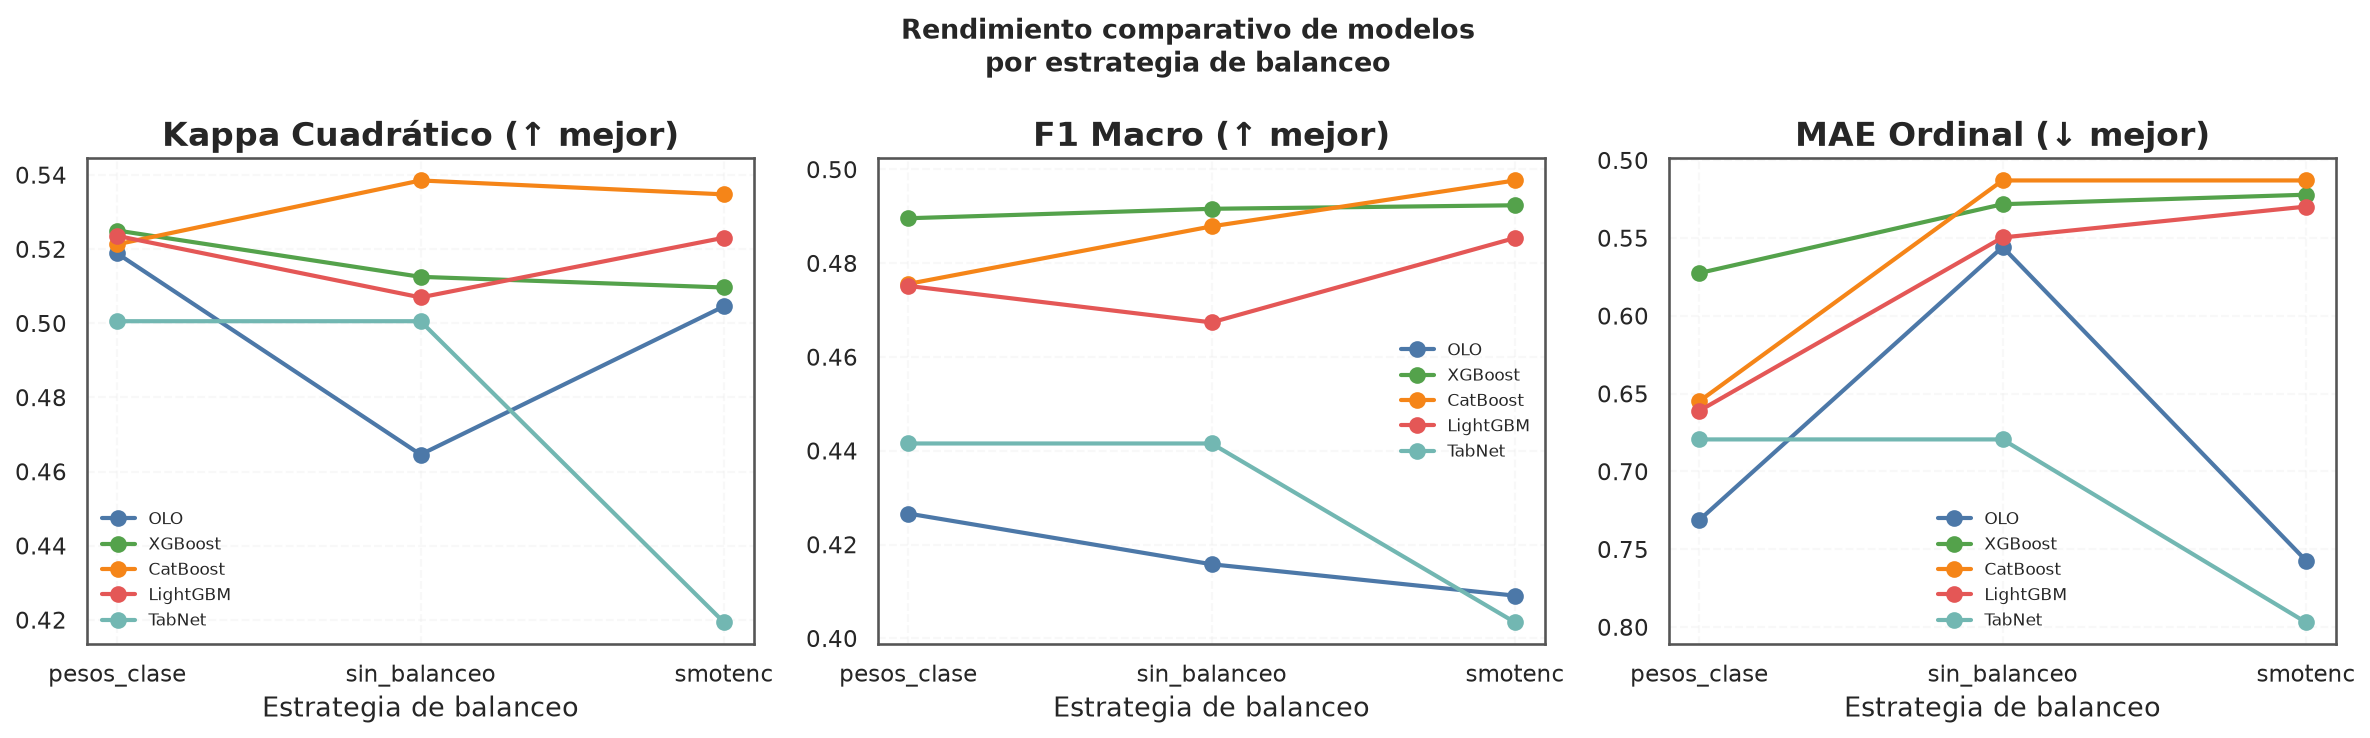

✓ Figura guardada: rendimiento_comparativo.png


In [30]:
# =============================================================================
# Gráficos de rendimiento por modelo y estrategia de balanceo
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Rendimiento comparativo de modelos\npor estrategia de balanceo",
    fontsize=13, fontweight="bold",
)

metricas_plot = [
    ("kappa_cuadratico", "Kappa Cuadrático (↑ mejor)"),
    ("f1_macro",         "F1 Macro (↑ mejor)"),
    ("mae_ordinal",      "MAE Ordinal (↓ mejor)"),
]
modelos_orden = ["OLO", "XGBoost", "CatBoost", "LightGBM", "TabNet"]
colores_dict  = {m: THEME["models"].get(m, "#888888") for m in modelos_orden}

for ax, (metrica, titulo) in zip(axes, metricas_plot):
    for modelo in modelos_orden:
        sub = df_res[(df_res["modelo"] == modelo) & (df_res["split"] == "test")]
        if sub.empty or metrica not in sub.columns:
            continue
        ax.plot(sub["estrategia_balanceo"], sub[metrica],
                marker="o", linewidth=2, markersize=7,
                label=modelo, color=colores_dict.get(modelo, "#888888"))
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel("Estrategia de balanceo")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    if metrica == "mae_ordinal":
        ax.invert_yaxis()

save_figure("rendimiento_comparativo")
plt.show()
print("✓ Figura guardada: rendimiento_comparativo.png")


## 22. Registro de versiones y entorno

In [31]:
# =============================================================================
# Registro de versiones para reproducibilidad
# =============================================================================
import importlib, platform, sys

libs = ["pandas","numpy","sklearn","xgboost","lightgbm",
        "catboost","pytorch_tabnet","optuna","torch","missingno","joblib"]

print(f"Fecha          : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python         : {sys.version.split()[0]}")
print(f"Sistema        : {platform.system()} {platform.release()}")
print(f"Semilla global : {PARAMETERS['SEED']}")
print(f"GPU usada      : {USAR_GPU}")
print()
print("Versiones de librerías:")
for lib in libs:
    try:
        ver = getattr(importlib.import_module(lib), "__version__", "N/D")
        print(f"  {lib:<20}: {ver}")
    except ImportError:
        print(f"  {lib:<20}: NO INSTALADA")

Fecha          : 2026-07-18 21:59:12
Python         : 3.12.3
Sistema        : Linux 6.17.0-35-generic
Semilla global : 42
GPU usada      : True

Versiones de librerías:
  pandas              : 3.0.3
  numpy               : 2.4.6
  sklearn             : 1.9.0
  xgboost             : 3.3.0
  lightgbm            : 4.6.0
  catboost            : 1.2.10
  pytorch_tabnet      : N/D
  optuna              : 4.9.0
  torch               : 2.13.0+cu130
  missingno           : 0.5.2
  joblib              : 1.5.3
